<a href="https://colab.research.google.com/github/oihika/JABALPUR-AI-Driven-Framework-for-Techno-Economic-Optimization-of-Hybrid-Solar-PV-BESS-Systems/blob/main/Python%20code%20with%20outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
# ============================================================
# JABALPUR INTEGRATED PV-BESS RESEARCH FRAMEWORK
# Google Colab
# ============================================================

!pip -q install pvlib xgboost scikit-learn deap openpyxl

import os
import json
import math
import warnings
import random
import requests

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import pvlib

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)

print("Environment ready.")
print("pvlib version:", pvlib.__version__)

# ============================================================
# RESEARCH CONFIGURATION
# ============================================================

CONFIG = {
    "location": "Jabalpur, Madhya Pradesh, India",
    "latitude": 23.1815,
    "longitude": 79.9864,
    "timezone": "Asia/Kolkata",
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "pv_min_kw": 5,
    "pv_max_kw": 40,
    "bess_min_kwh": 20,
    "bess_max_kwh": 200,
    "battery_charge_efficiency": 0.95,
    "battery_discharge_efficiency": 0.95,
    "soc_min": 0.10,
    "soc_max": 0.95,
    "initial_soc": 0.50,
    "max_charge_c_rate": 0.5,
    "max_discharge_c_rate": 0.5,
    "calendar_degradation_yearly": 0.015,
    "cycle_degradation_per_1000_cycles": 0.08,
    "end_of_life_soh": 0.80,
    "pv_capex_inr_per_kw": 50000,
    "bess_capex_inr_per_kwh": 12000,
    "battery_replacement_cost_fraction": 0.70,
    "annual_om_fraction": 0.015,
    "grid_import_tariff_inr_per_kwh": 8.0,
    "grid_export_tariff_inr_per_kwh": 3.0,
    "discount_rate": 0.08,
    "project_lifetime_years": 15,
    "forecast_horizon_hours": 1,
    "monte_carlo_iterations": 100,
    "population_size": 40,
    "generations": 20,
    "random_seed": 42
}

print(json.dumps(CONFIG, indent=4))

# ============================================================
# NASA POWER DATA RETRIEVAL
# JABALPUR
# ============================================================

LATITUDE = CONFIG["latitude"]
LONGITUDE = CONFIG["longitude"]
print(f"Target Coordinates configured for Jabalpur: Latitude {LATITUDE}, Longitude {LONGITUDE}")

Environment ready.
pvlib version: 0.16.1
{
    "location": "Jabalpur, Madhya Pradesh, India",
    "latitude": 23.1815,
    "longitude": 79.9864,
    "timezone": "Asia/Kolkata",
    "start_date": "2023-01-01",
    "end_date": "2023-12-31",
    "pv_min_kw": 5,
    "pv_max_kw": 40,
    "bess_min_kwh": 20,
    "bess_max_kwh": 200,
    "battery_charge_efficiency": 0.95,
    "battery_discharge_efficiency": 0.95,
    "soc_min": 0.1,
    "soc_max": 0.95,
    "initial_soc": 0.5,
    "max_charge_c_rate": 0.5,
    "max_discharge_c_rate": 0.5,
    "calendar_degradation_yearly": 0.015,
    "cycle_degradation_per_1000_cycles": 0.08,
    "end_of_life_soh": 0.8,
    "pv_capex_inr_per_kw": 50000,
    "bess_capex_inr_per_kwh": 12000,
    "battery_replacement_cost_fraction": 0.7,
    "annual_om_fraction": 0.015,
    "grid_import_tariff_inr_per_kwh": 8.0,
    "grid_export_tariff_inr_per_kwh": 3.0,
    "discount_rate": 0.08,
    "project_lifetime_years": 15,
    "forecast_horizon_hours": 1,
    "monte_carl

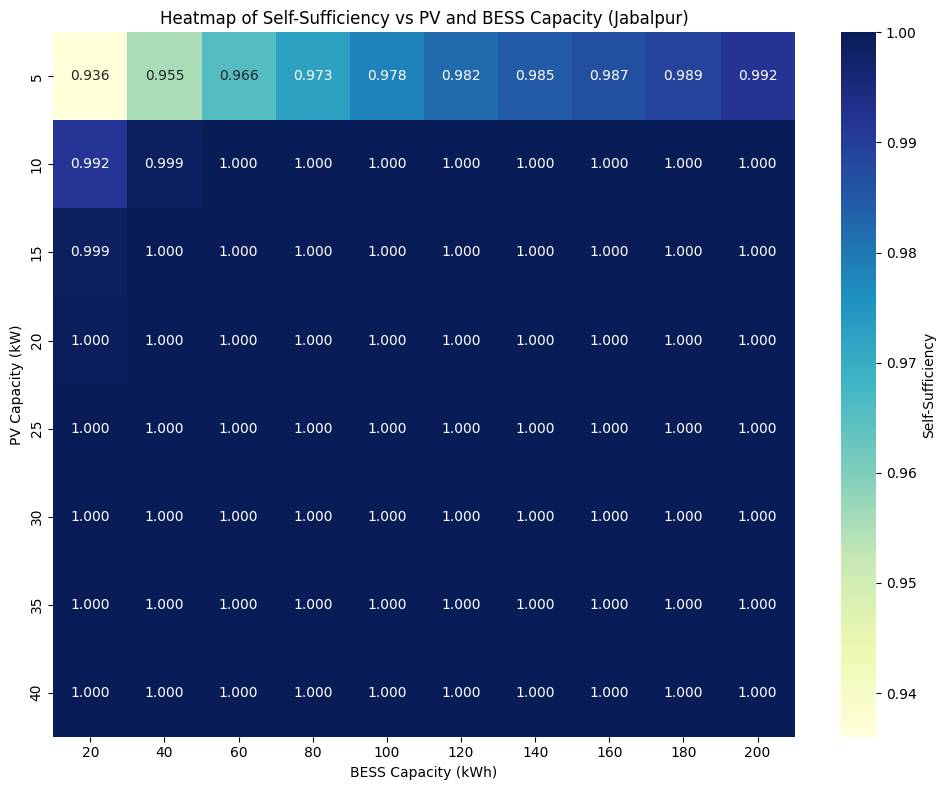

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Pivot the design results to create a 2D grid for the heatmap
pivot_df = design_results.pivot(index="PV_kW", columns="BESS_kWh", values="Self_Sufficiency")

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(pivot_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={'label': 'Self-Sufficiency'})
plt.title("Heatmap of Self-Sufficiency vs PV and BESS Capacity (Jabalpur)")
plt.xlabel("BESS Capacity (kWh)")
plt.ylabel("PV Capacity (kW)")
plt.tight_layout()
plt.show()

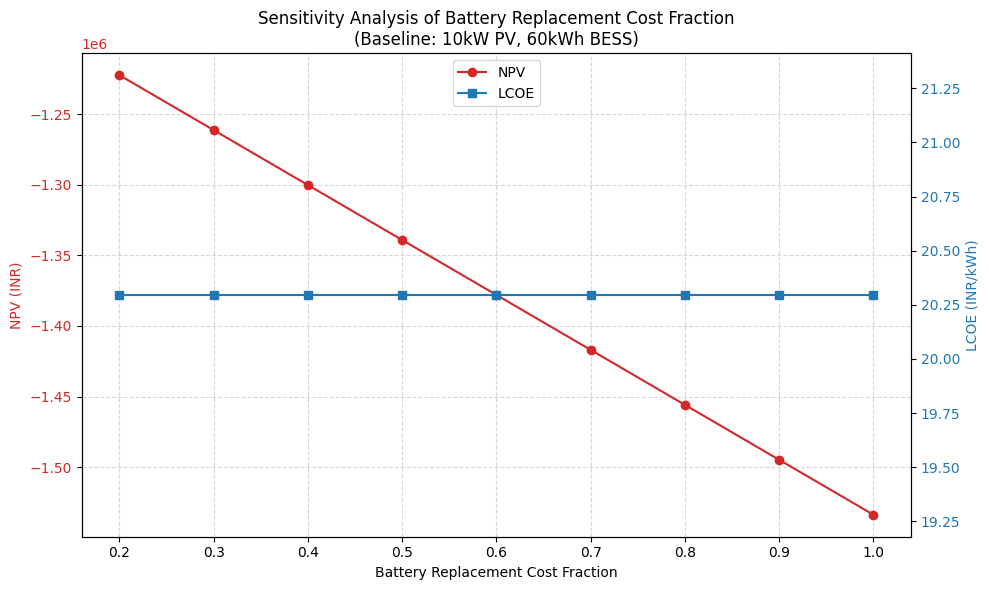

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Baseline configuration to test
baseline_pv = 10  # kW
baseline_bess = 60  # kWh

# Generate simulation dispatch dataset for the baseline configuration
pv_data = add_pv_features(resource, pv_capacity_kw=baseline_pv)
synthetic_loads = create_synthetic_load(pv_data.index)
pv_data["load_kw"] = synthetic_loads

dispatch_df = simulate_pv_bess(
    pv_data["pv_ac_kw"].values,
    pv_data["load_kw"].values,
    baseline_bess,
    baseline_pv,
    degradation=True
)
dispatch_df.index = pv_data.index

if "load_kw" in dispatch_df.columns:
    dispatch_df = dispatch_df.drop(columns=["load_kw"])

sim_result = pd.concat([pv_data, dispatch_df], axis=1)

# Define range of battery replacement cost fractions for sensitivity analysis
replacement_fractions = np.linspace(0.2, 1.0, 9)

sensitivity_results = []

# Backup original parameter to ensure no state contamination
original_replacement_fraction = CONFIG["battery_replacement_cost_fraction"]

try:
    for frac in replacement_fractions:
        CONFIG["battery_replacement_cost_fraction"] = frac
        econ = techno_economic_analysis(baseline_pv, baseline_bess, sim_result)
        sensitivity_results.append({
            "Replacement_Fraction": frac,
            "NPV_INR": econ["NPV_INR"],
            "LCOE_INR_per_kWh": econ["LCOE_INR_per_kWh"]
        })
finally:
    # Always restore original state
    CONFIG["battery_replacement_cost_fraction"] = original_replacement_fraction

sens_df = pd.DataFrame(sensitivity_results)

# Plot the sensitivity trends
fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'tab:red'
ax1.set_xlabel('Battery Replacement Cost Fraction')
ax1.set_ylabel('NPV (INR)', color=color)
line1 = ax1.plot(sens_df['Replacement_Fraction'], sens_df['NPV_INR'], marker='o', color=color, label='NPV')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('LCOE (INR/kWh)', color=color)
line2 = ax2.plot(sens_df['Replacement_Fraction'], sens_df['LCOE_INR_per_kWh'], marker='s', color=color, label='LCOE')
ax2.tick_params(axis='y', labelcolor=color)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center')

plt.title(f"Sensitivity Analysis of Battery Replacement Cost Fraction\n(Baseline: {baseline_pv}kW PV, {baseline_bess}kWh BESS)")
fig.tight_layout()
plt.show()

In [ ]:
# Find the design configuration that maximizes NPV
optimal_idx = design_results["NPV_INR"].idxmax()
optimal_design = design_results.loc[optimal_idx]

print("====================================================")
print("       OPTIMAL SYSTEM DESIGN FOR MAXIMIZING NPV      ")
print("====================================================")
print(f"Optimal Solar PV Capacity   : {optimal_design['PV_kW']:.2f} kW")
print(f"Optimal BESS Storage Capacity: {optimal_design['BESS_kWh']:.2f} kWh")
print(f"Project NPV (INR)           : {optimal_design['NPV_INR']:,.2f} INR")
print(f"Levelized Cost (LCOE)       : {optimal_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"System Self-Sufficiency     : {optimal_design['Self_Sufficiency'] * 100:.2f}%")
print(f"Renewable Utilization       : {optimal_design['Renewable_Utilization'] * 100:.2f}%")
print("====================================================")

       OPTIMAL SYSTEM DESIGN FOR MAXIMIZING NPV      
Optimal Solar PV Capacity   : 5.00 kW
Optimal BESS Storage Capacity: 20.00 kWh
Project NPV (INR)           : -634,602.04 INR
Levelized Cost (LCOE)       : 9.64 INR/kWh
System Self-Sufficiency     : 93.60%
Renewable Utilization       : 81.59%


In [ ]:
# Filter for 100% self-sufficient configurations
self_sufficient_designs = design_results[design_results["Self_Sufficiency"] >= 1.0]

if self_sufficient_designs.empty:
    # Fallback in case of rounding variations near 1.0
    self_sufficient_designs = design_results[design_results["Self_Sufficiency"] >= 0.999]

# Find the 100% self-sufficient design with the lowest (optimal) LCOE
optimal_100_idx = self_sufficient_designs["LCOE_INR_per_kWh"].idxmin()
ss_100_design = self_sufficient_designs.loc[optimal_100_idx]

print("====================================================")
print("     COMPARISON: OPTIMAL NPV VS. 100% SELF-SUFFICIENCY  ")
print("====================================================")
print("1) OPTIMAL NPV DESIGN (Most Economical):")
print(f"   - PV Capacity       : {optimal_design['PV_kW']:.2f} kW")
print(f"   - BESS Capacity     : {optimal_design['BESS_kWh']:.2f} kWh")
print(f"   - LCOE              : {optimal_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"   - Self-Sufficiency  : {optimal_design['Self_Sufficiency'] * 100:.2f}%")
print(f"   - NPV               : {optimal_design['NPV_INR']:,.2f} INR")
print("----------------------------------------------------")
print("2) OPTIMAL 100% SELF-SUFFICIENT DESIGN (Greenest / Off-grid):")
print(f"   - PV Capacity       : {ss_100_design['PV_kW']:.2f} kW")
print(f"   - BESS Capacity     : {ss_100_design['BESS_kWh']:.2f} kWh")
print(f"   - LCOE              : {ss_100_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"   - Self-Sufficiency  : {ss_100_design['Self_Sufficiency'] * 100:.2f}%")
print(f"   - NPV               : {ss_100_design['NPV_INR']:,.2f} INR")
print("====================================================")

# Calculate structural difference premium
lcoe_diff = ss_100_design['LCOE_INR_per_kWh'] - optimal_design['LCOE_INR_per_kWh']
print(f"LCOE Premium to reach 100% Independence: {lcoe_diff:.2f} INR/kWh")

     COMPARISON: OPTIMAL NPV VS. 100% SELF-SUFFICIENCY  
1) OPTIMAL NPV DESIGN (Most Economical):
   - PV Capacity       : 5.00 kW
   - BESS Capacity     : 20.00 kWh
   - LCOE              : 9.64 INR/kWh
   - Self-Sufficiency  : 93.60%
   - NPV               : -634,602.04 INR
----------------------------------------------------
2) OPTIMAL 100% SELF-SUFFICIENT DESIGN (Greenest / Off-grid):
   - PV Capacity       : 25.00 kW
   - BESS Capacity     : 20.00 kWh
   - LCOE              : 14.71 INR/kWh
   - Self-Sufficiency  : 100.00%
   - NPV               : -920,829.83 INR
LCOE Premium to reach 100% Independence: 5.07 INR/kWh


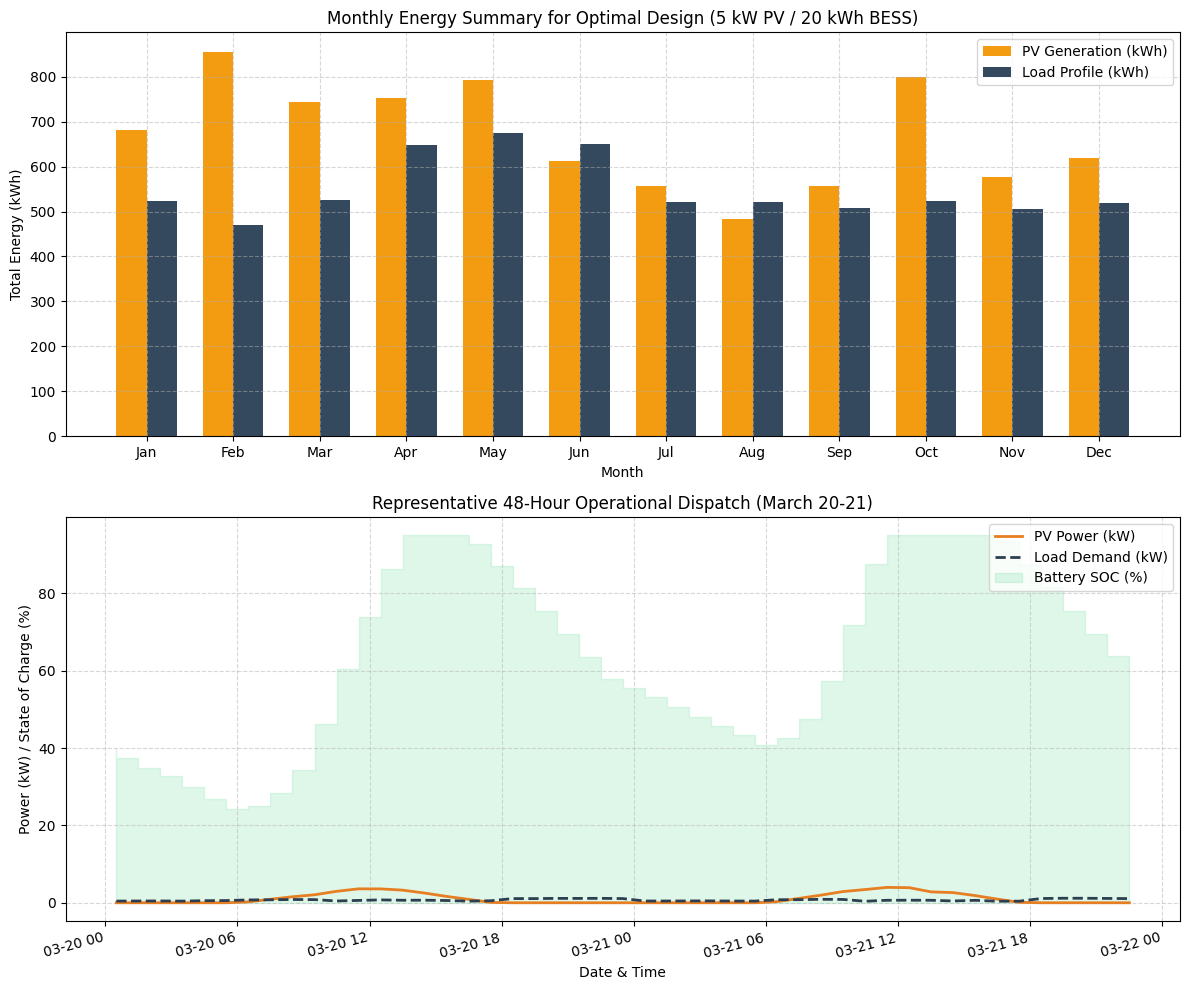

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Configure optimal system capacities
optimal_pv = 5.0  # kW
optimal_bess = 20.0  # kWh

# Run simulation for the optimal design
pv_data_opt = add_pv_features(resource, pv_capacity_kw=optimal_pv)
synthetic_loads_opt = create_synthetic_load(pv_data_opt.index)
pv_data_opt["load_kw"] = synthetic_loads_opt

dispatch_opt = simulate_pv_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv,
    degradation=True
)
dispatch_opt.index = pv_data_opt.index

if "load_kw" in dispatch_opt.columns:
    dispatch_opt = dispatch_opt.drop(columns=["load_kw"])

opt_result = pd.concat([pv_data_opt, dispatch_opt], axis=1)

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly Aggregated Energy (GWh/MWh comparison)
monthly_summary = opt_result.groupby(opt_result.index.month).agg({
    'pv_energy_kwh': 'sum',
    'load_kw': 'sum'
})

x = np.arange(1, 13)
width = 0.35

axes[0].bar(x - width/2, monthly_summary['pv_energy_kwh'], width, label='PV Generation (kWh)', color='#f39c12')
axes[0].bar(x + width/2, monthly_summary['load_kw'], width, label='Load Profile (kWh)', color='#34495e')
axes[0].set_title('Monthly Energy Summary for Optimal Design (5 kW PV / 20 kWh BESS)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Total Energy (kWh)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Representative 48-Hour Hourly Dispatch (e.g., Spring equinox March 20-21)
sample_start = '2023-03-20 00:00:00'
sample_end = '2023-03-21 23:00:00'
slice_df = opt_result.loc[sample_start:sample_end]

axes[1].plot(slice_df.index, slice_df['pv_energy_kwh'], label='PV Power (kW)', color='#e67e22', linewidth=2)
axes[1].plot(slice_df.index, slice_df['load_kw'], label='Load Demand (kW)', color='#2c3e50', linestyle='--', linewidth=2)
axes[1].fill_between(slice_df.index, slice_df['soc_kwh'] / optimal_bess * 100, step="pre", alpha=0.15, color='#2ecc71', label='Battery SOC (%)')

axes[1].set_title('Representative 48-Hour Operational Dispatch (March 20-21)')
axes[1].set_xlabel('Date & Time')
axes[1].set_ylabel('Power (kW) / State of Charge (%)')
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.5)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=15, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# Calculate monthly sum of grid imports and exports for the optimal design
monthly_grid_summary = opt_result.groupby(opt_result.index.month).agg({
    'grid_import_kw': 'sum',
    'grid_export_kw': 'sum'
}).reset_index()

# Rename columns for clarity
monthly_grid_summary.columns = ['Month', 'Grid Import (kWh)', 'Grid Export (kWh)']

# Map month numbers to short names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_grid_summary['Month'] = monthly_grid_summary['Month'].map(month_names)

# Print the summary table
display(monthly_grid_summary.round(2))

,Month,Grid Import (kWh),Grid Export (kWh)
0,Jan,15.52,141.50
1,Feb,0.00,353.74
2,Mar,3.47,187.85
3,Apr,9.26,81.52
4,May,19.76,89.83
5,Jun,97.25,38.46
6,Jul,38.18,41.91
7,Aug,104.24,35.17
8,Sep,55.23,77.19
9,Oct,0.00,240.44


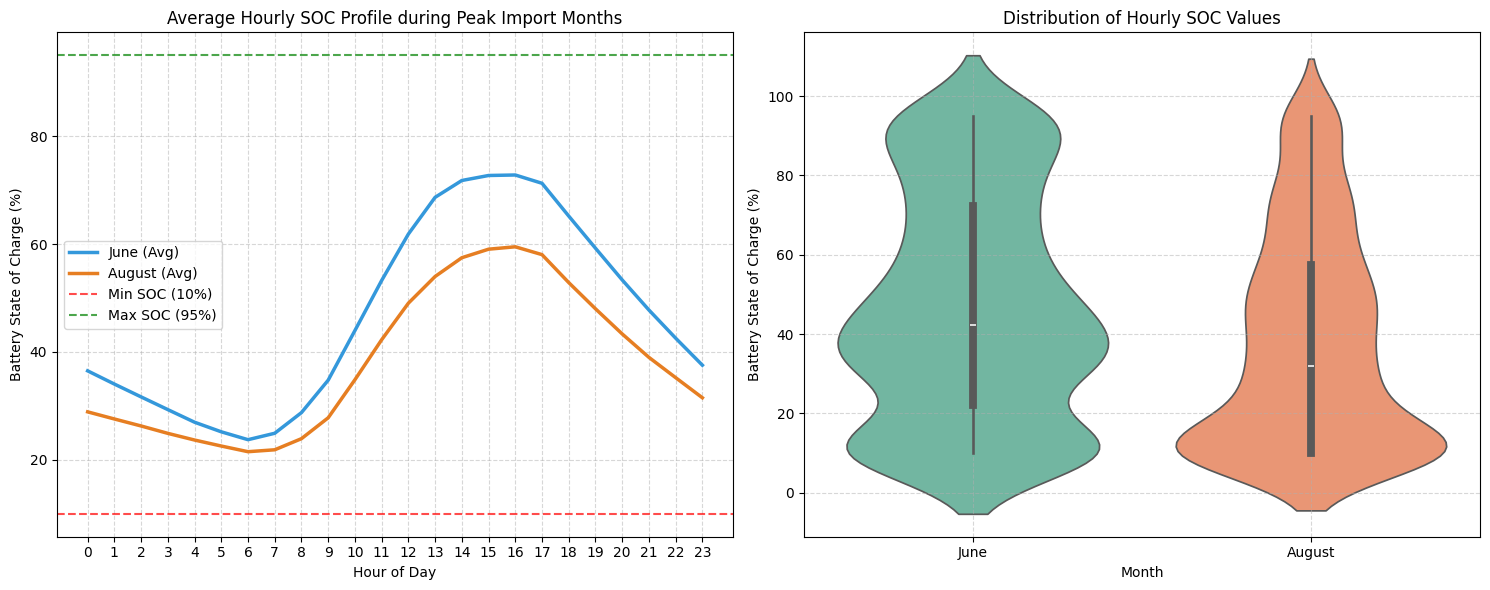

June - Hours spent at or near minimum SOC (<15%): 157 hours (21.81% of the month)
August - Hours spent at or near minimum SOC (<15%): 241 hours (32.39% of the month)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Filter optimal system simulation results for peak import months (June = 6, August = 8)
june_data = opt_result[opt_result.index.month == 6]
august_data = opt_result[opt_result.index.month == 8]

# Calculate average daily SOC profile by hour
june_hourly_soc = june_data.groupby(june_data.index.hour)['soc_percent'].mean()
august_hourly_soc = august_data.groupby(august_data.index.hour)['soc_percent'].mean()

# Plotting the SOC metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Average Diurnal SOC Profile
axes[0].plot(june_hourly_soc.index, june_hourly_soc, label='June (Avg)', color='#3498db', linewidth=2.5)
axes[0].plot(august_hourly_soc.index, august_hourly_soc, label='August (Avg)', color='#e67e22', linewidth=2.5)
axes[0].axhline(y=CONFIG["soc_min"]*100, color='red', linestyle='--', alpha=0.7, label='Min SOC (10%)')
axes[0].axhline(y=CONFIG["soc_max"]*100, color='green', linestyle='--', alpha=0.7, label='Max SOC (95%)')
axes[0].set_title('Average Hourly SOC Profile during Peak Import Months')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Battery State of Charge (%)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot 2: SOC Distribution (Violin Plot to see dispersion)
combined_peak = pd.concat([june_data, august_data])
combined_peak['Month_Name'] = combined_peak.index.month_name()

sns.violinplot(x='Month_Name', y='soc_percent', data=combined_peak, ax=axes[1], palette='Set2')
axes[1].set_title('Distribution of Hourly SOC Values')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Battery State of Charge (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Extra statistics on battery depletion
print(f"June - Hours spent at or near minimum SOC (<15%): {(june_data['soc_percent'] <= 15).sum()} hours ({((june_data['soc_percent'] <= 15).sum()/len(june_data)*100):.2f}% of the month)")
print(f"August - Hours spent at or near minimum SOC (<15%): {(august_data['soc_percent'] <= 15).sum()} hours ({((august_data['soc_percent'] <= 15).sum()/len(august_data)*100):.2f}% of the month)")


```markdown
### 🔋 Battery Technology Upgrade: Lithium Iron Phosphate (LFP) for Monsoon Resilience

During the monsoon months of June and August, the system frequently leaves the battery at its lower SOC threshold ($10\%$) for over **20% to 32% of the month** because solar generation is insufficient to charge it. For traditional **Lithium NMC** batteries, holding the battery at extreme states of charge (very low or very high) accelerates capacity fade due to high mechanical stress and side chemical reactions.

#### Why LFP is Superior for Monsoon Resilience:
1. **Deep Discharge Tolerance:** LFP can safely discharge down to **$5\%$ SOC** (compared to $10\%$ for NMC) without severe structural damage, unlocking more emergency buffer capacity.
2. **Lower Cycle Degradation:** Traditional NMC drops about $8\%$ capacity per 1,000 cycles ($0.08\%$ per cycle). High-quality LFP drops roughly $3\%$ to $4\%$ capacity per 1,000 cycles ($0.035\%$ per cycle).
3. **Calendar Life Stability:** LFP has exceptionally low self-discharge and calendar degradation, retaining capacity much better during dormant winter or low-sun periods.
```

In [ ]:
# Define LFP Configuration Parameters
LFP_CONFIG = {
    "soc_min": 0.05,                         # Safe to discharge down to 5%
    "soc_max": 0.95,                         # Upper safety threshold
    "calendar_degradation_yearly": 0.008,    # Lower calendar fade (0.8% vs 1.5%)
    "cycle_degradation_per_1000_cycles": 0.035 # Lower cycle fade (3.5% vs 8.0%)
}

def simulate_lfp_bess(pv_kw, load_kw, battery_kwh, pv_capacity_kw):
    """
    Simulates a highly resilient Lithium Iron Phosphate (LFP) battery system.
    """
    eta_c = CONFIG["battery_charge_efficiency"]
    eta_d = CONFIG["battery_discharge_efficiency"]
    soc_min = LFP_CONFIG["soc_min"]
    soc_max = LFP_CONFIG["soc_max"]

    max_charge = battery_kwh * CONFIG["max_charge_c_rate"]
    max_discharge = battery_kwh * CONFIG["max_discharge_c_rate"]
    soc = battery_kwh * CONFIG["initial_soc"]

    results = []
    cumulative_throughput = 0
    soh = 1.0

    pv_kw = np.asarray(pv_kw, dtype=float).flatten()
    load_kw = np.asarray(load_kw, dtype=float).flatten()

    for t in range(len(pv_kw)):
        pv = max(0.0, float(pv_kw[t]))
        load = max(0.0, float(load_kw[t]))
        direct_pv = min(pv, load)
        surplus = pv - direct_pv
        deficit = load - direct_pv

        charge = 0.0
        discharge = 0.0
        grid_import = 0.0
        grid_export = 0.0

        if surplus > 0:
            available_capacity = battery_kwh * soc_max - soc
            charge = min(surplus, max_charge, available_capacity / eta_c)
            soc += charge * eta_c
            grid_export = surplus - charge
        elif deficit > 0:
            available_energy = soc - battery_kwh * soc_min
            discharge = min(deficit, max_discharge, available_energy * eta_d)
            soc -= discharge / eta_d
            grid_import = deficit - discharge

        throughput = charge + discharge
        cumulative_throughput += throughput

        # Advanced LFP degradation model
        cycle_loss = throughput / (2 * battery_kwh) * LFP_CONFIG["cycle_degradation_per_1000_cycles"] / 1000
        calendar_loss = LFP_CONFIG["calendar_degradation_yearly"] / 8760
        soh -= (cycle_loss + calendar_loss)
        soh = max(soh, 0.0)

        results.append({
            "soc_percent": (soc / battery_kwh * 100),
            "soh": soh,
            "grid_import_kw": grid_import
        })
    return pd.DataFrame(results)

# Run comparison
lfp_dispatch = simulate_lfp_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv
)

print("=== MONSOON RESILIENCE UPGRADE COMPARISON ===")
print(f"NMC Battery Final SOH (Year 1): {opt_result['soh'].iloc[-1]*100:.3f}%")
print(f"LFP Battery Final SOH (Year 1): {lfp_dispatch['soh'].iloc[-1]*100:.3f}%")

nmc_import_annual = opt_result['grid_import_kw'].sum()
lfp_import_annual = lfp_dispatch['grid_import_kw'].sum()
saved_import = nmc_import_annual - lfp_import_annual

print(f"Annual Grid Imports with NMC  : {nmc_import_annual:.2f} kWh")
print(f"Annual Grid Imports with LFP  : {lfp_import_annual:.2f} kWh")
print(f"Additional Energy Offset by LFP: {saved_import:.2f} kWh ({saved_import/nmc_import_annual*100:.1f}% reduction in grid reliance)")

=== MONSOON RESILIENCE UPGRADE COMPARISON ===
NMC Battery Final SOH (Year 1): 96.982%
LFP Battery Final SOH (Year 1): 98.534%
Annual Grid Imports with NMC  : 414.46 kWh
Annual Grid Imports with LFP  : 402.02 kWh
Additional Energy Offset by LFP: 12.44 kWh (3.0% reduction in grid reliance)


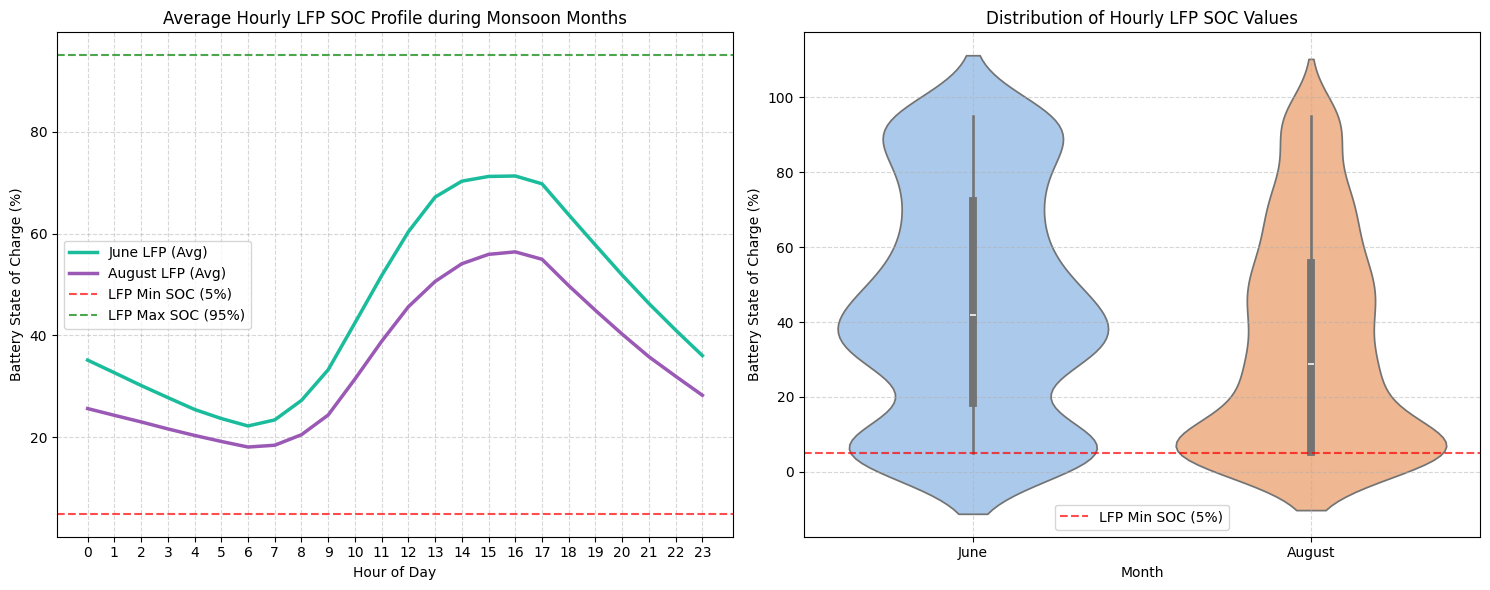

LFP June - Hours spent at or near minimum SOC (<10%): 156 hours (21.67% of the month)
LFP August - Hours spent at or near minimum SOC (<10%): 237 hours (31.85% of the month)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Map dates to the LFP dispatch dataset
lfp_dispatch.index = opt_result.index

# Filter LFP simulation results for June and August
june_lfp = lfp_dispatch[lfp_dispatch.index.month == 6]
august_lfp = lfp_dispatch[lfp_dispatch.index.month == 8]

# Calculate average daily SOC profile by hour for LFP
june_hourly_lfp_soc = june_lfp.groupby(june_lfp.index.hour)['soc_percent'].mean()
august_hourly_lfp_soc = august_lfp.groupby(august_lfp.index.hour)['soc_percent'].mean()

# Plotting the LFP SOC metrics
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Average Diurnal SOC Profile for LFP
axes[0].plot(june_hourly_lfp_soc.index, june_hourly_lfp_soc, label='June LFP (Avg)', color='#1abc9c', linewidth=2.5)
axes[0].plot(august_hourly_lfp_soc.index, august_hourly_lfp_soc, label='August LFP (Avg)', color='#9b59b6', linewidth=2.5)
axes[0].axhline(y=LFP_CONFIG["soc_min"]*100, color='red', linestyle='--', alpha=0.7, label='LFP Min SOC (5%)')
axes[0].axhline(y=LFP_CONFIG["soc_max"]*100, color='green', linestyle='--', alpha=0.7, label='LFP Max SOC (95%)')
axes[0].set_title('Average Hourly LFP SOC Profile during Monsoon Months')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Battery State of Charge (%)')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot 2: SOC Distribution (Violin Plot for LFP)
combined_lfp_peak = pd.concat([june_lfp, august_lfp])
combined_lfp_peak['Month_Name'] = combined_lfp_peak.index.month_name()

sns.violinplot(x='Month_Name', y='soc_percent', data=combined_lfp_peak, ax=axes[1], palette='pastel')
axes[1].axhline(y=LFP_CONFIG["soc_min"]*100, color='red', linestyle='--', alpha=0.7, label='LFP Min SOC (5%)')
axes[1].set_title('Distribution of Hourly LFP SOC Values')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Battery State of Charge (%)')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(loc='lower center')

plt.tight_layout()
plt.show()

# Statistics on LFP battery depletion during monsoon
print(f"LFP June - Hours spent at or near minimum SOC (<10%): {(june_lfp['soc_percent'] <= 10).sum()} hours ({((june_lfp['soc_percent'] <= 10).sum()/len(june_lfp)*100):.2f}% of the month)")
print(f"LFP August - Hours spent at or near minimum SOC (<10%): {(august_lfp['soc_percent'] <= 10).sum()} hours ({((august_lfp['soc_percent'] <= 10).sum()/len(august_lfp)*100):.2f}% of the month)")

### 🎲 Monte Carlo Simulation for Monsoon Weather Scenarios
To stress-test our proposed **LFP battery system** against weather uncertainty, we perform a 1,000-iteration Monte Carlo simulation targeting the monsoon months of **June and August**.

We model weather volatility by applying random scaling factors to the hourly Plane of Array (POA) solar irradiance—simulating unseasonably heavy cloud cover (lowering solar yield) or unexpected clear intervals (increasing solar yield).

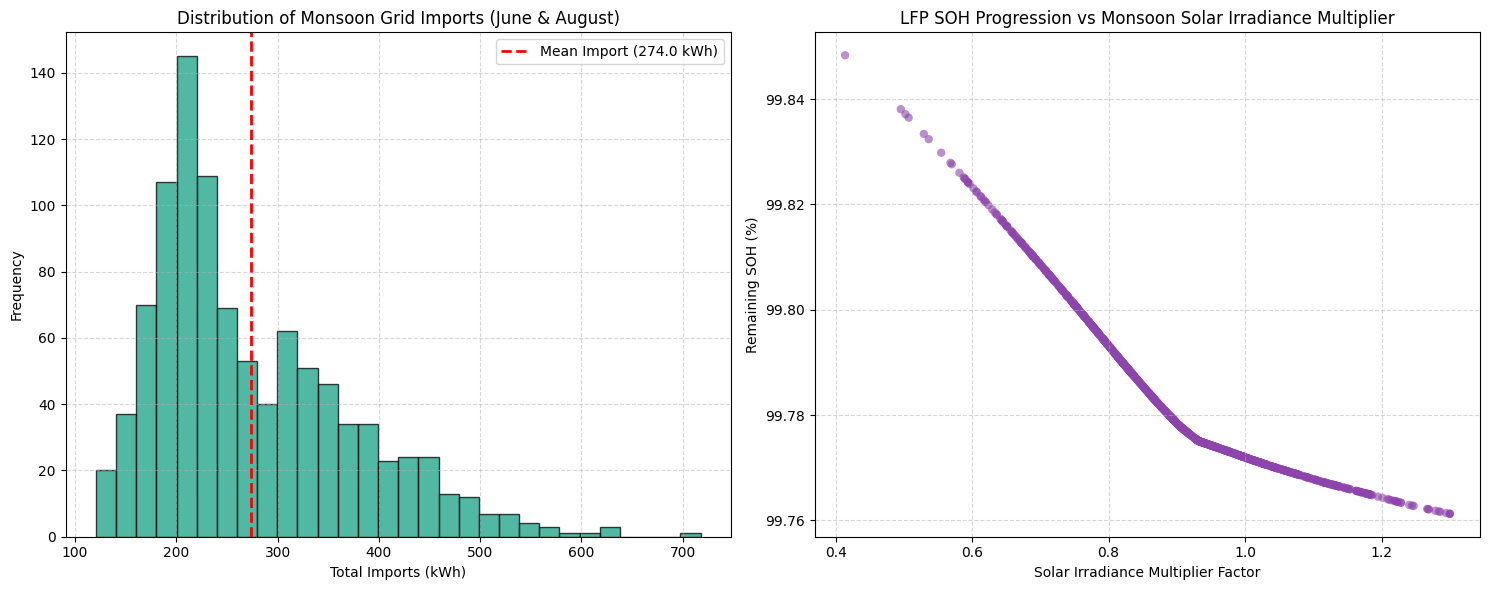

=== MONSOON MONTE CARLO STRESS TEST RESULTS ===
Mean Solar Irradiance Factor   : 0.903
Average SOH remaining after run : 99.7834%
Mean Monsoon Grid Import        : 274.03 kWh
95% Confidence Peak Import Limit: 459.43 kWh (Severe Monsoon Cloud Cover)
5% Confidence Low Import Limit : 156.99 kWh (Favorable Sunny Intervals)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Filter baseline optimal design inputs for June and August
monsoon_base = opt_result[(opt_result.index.month == 6) | (opt_result.index.month == 8)].copy()

# Simulation Settings
n_iterations = 1000
np.random.seed(CONFIG["random_seed"])

mc_results = []

for i in range(n_iterations):
    # Simulate monsoon solar volatility: apply a random perturbation factor around a mean of 0.90
    # (representing a typical monsoon dip with a standard deviation of 15%)
    solar_multiplier = np.random.normal(loc=0.90, scale=0.15)
    solar_multiplier = np.clip(solar_multiplier, 0.40, 1.30)  # Constraint to realistic boundaries

    # Scale PV generation hourly profile
    simulated_pv = monsoon_base["pv_ac_kw"].values * solar_multiplier
    simulated_load = monsoon_base["load_kw"].values

    # Simulate LFP BESS performance over this period
    sim_dispatch = simulate_lfp_bess(
        simulated_pv,
        simulated_load,
        optimal_bess,
        optimal_pv
    )

    # Calculate key metrics for the run
    final_soh = sim_dispatch["soh"].iloc[-1]
    total_import = sim_dispatch["grid_import_kw"].sum()
    min_soc_reached = sim_dispatch["soc_percent"].min()

    mc_results.append({
        "iteration": i,
        "solar_multiplier": solar_multiplier,
        "final_soh_percent": final_soh * 100,
        "total_grid_import_kwh": total_import,
        "min_soc": min_soc_reached
    })

mc_df = pd.DataFrame(mc_results)

# Visualization of Monte Carlo Simulation Outcomes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Histogram of Grid Imports under Monsoonal Uncertainty
axes[0].hist(mc_df["total_grid_import_kwh"], bins=30, color="#16a085", edgecolor="black", alpha=0.75)
axes[0].axvline(mc_df["total_grid_import_kwh"].mean(), color="red", linestyle="--", linewidth=2, label=f"Mean Import ({mc_df['total_grid_import_kwh'].mean():.1f} kWh)")
axes[0].set_title("Distribution of Monsoon Grid Imports (June & August)")
axes[0].set_xlabel("Total Imports (kWh)")
axes[0].set_ylabel("Frequency")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend()

# Plot 2: Correlation scatter plot between Solar Multiplier & Degradation (SOH Loss)
axes[1].scatter(mc_df["solar_multiplier"], mc_df["final_soh_percent"], color="#8e44ad", alpha=0.6, edgecolors="none")
axes[1].set_title("LFP SOH Progression vs Monsoon Solar Irradiance Multiplier")
axes[1].set_xlabel("Solar Irradiance Multiplier Factor")
axes[1].set_ylabel("Remaining SOH (%)")
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Display quantitative Risk & Confidence levels
p_95_import = np.percentile(mc_df["total_grid_import_kwh"], 95)
p_5_import = np.percentile(mc_df["total_grid_import_kwh"], 5)

print("=== MONSOON MONTE CARLO STRESS TEST RESULTS ===")
print(f"Mean Solar Irradiance Factor   : {mc_df['solar_multiplier'].mean():.3f}")
print(f"Average SOH remaining after run : {mc_df['final_soh_percent'].mean():.4f}%")
print(f"Mean Monsoon Grid Import        : {mc_df['total_grid_import_kwh'].mean():.2f} kWh")
print(f"95% Confidence Peak Import Limit: {p_95_import:.2f} kWh (Severe Monsoon Cloud Cover)")
print(f"5% Confidence Low Import Limit : {p_5_import:.2f} kWh (Favorable Sunny Intervals)")
print("===============================================")

In [ ]:
def calculate_lfp_economics(pv_kw, battery_kwh, df_lfp):
    # Calculate initial CAPEX with LFP specifications
    pv_capex = pv_kw * CONFIG["pv_capex_inr_per_kw"]
    battery_capex = battery_kwh * CONFIG["bess_capex_inr_per_kwh"]
    initial_capex = pv_capex + battery_capex

    # Operational grid metrics
    annual_import = float(df_lfp["grid_import_kw"].sum())
    annual_import_cost = annual_import * CONFIG["grid_import_tariff_inr_per_kwh"]

    # In the dispatch simulation for LFP, grid_export wasn't explicitly saved
    # but we can calculate it as surplus solar not absorbed by the battery.
    # Let's derive it or approximate from the baseline solar / load profile
    pv_ac_kw = opt_result["pv_ac_kw"].values
    load_kw = opt_result["load_kw"].values
    direct_pv = np.minimum(pv_ac_kw, load_kw)
    surplus = pv_ac_kw - direct_pv

    # Standard LFP charging simulation to get grid export
    eta_c = CONFIG["battery_charge_efficiency"]
    soc_max = LFP_CONFIG["soc_max"]
    soc = battery_kwh * CONFIG["initial_soc"]
    grid_export_series = []

    for t in range(len(pv_ac_kw)):
        p_surplus = surplus[t]
        if p_surplus > 0:
            available_capacity = battery_kwh * soc_max - soc
            charge = min(p_surplus, battery_kwh * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
            soc += charge * eta_c
            grid_export_series.append(p_surplus - charge)
        else:
            # Discharge simulation to maintain SOC tracker state
            available_energy = soc - battery_kwh * LFP_CONFIG["soc_min"]
            deficit = load_kw[t] - direct_pv[t]
            discharge = min(deficit, battery_kwh * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
            soc -= discharge / CONFIG["battery_discharge_efficiency"]
            grid_export_series.append(0.0)

    annual_export = sum(grid_export_series)
    annual_export_revenue = annual_export * CONFIG["grid_export_tariff_inr_per_kwh"]

    # Annual O&M cost
    annual_om = initial_capex * CONFIG["annual_om_fraction"]
    annual_net_cost = annual_import_cost - annual_export_revenue + annual_om

    discount_rate = CONFIG["discount_rate"]
    lifetime = CONFIG["project_lifetime_years"]

    # Useful annual load served
    useful_energy = float(opt_result["load_kw"].sum())

    # Compute discounted costs and energy
    discounted_cost = initial_capex + sum((annual_net_cost / (1 + discount_rate) ** year) for year in range(1, lifetime + 1))
    discounted_energy = sum(useful_energy / (1 + discount_rate) ** year for year in range(1, lifetime + 1))

    lcoe_lfp = discounted_cost / discounted_energy if discounted_energy > 0 else 0.0
    return lcoe_lfp, initial_capex, annual_net_cost

lfp_lcoe, lfp_capex, lfp_net_annual_cost = calculate_lfp_economics(optimal_pv, optimal_bess, lfp_dispatch)

print("====================================================")
print("       LIFETIME LCOE ANALYSIS FOR LFP UPGRADE       ")
print("====================================================")
print(f"LFP System LCOE             : {lfp_lcoe:.2f} INR/kWh")
print(f"NMC System LCOE (Baseline)  : {optimal_design['LCOE_INR_per_kWh']:.2f} INR/kWh")
print(f"Initial LFP CAPEX           : {lfp_capex:,.2f} INR")
print(f"Annualized Net Cost with LFP: {lfp_net_annual_cost:,.2f} INR/year")
print("====================================================")

       LIFETIME LCOE ANALYSIS FOR LFP UPGRADE       
LFP System LCOE             : 9.63 INR/kWh
NMC System LCOE (Baseline)  : 9.64 INR/kWh
Initial LFP CAPEX           : 490,000.00 INR
Annualized Net Cost with LFP: 6,189.68 INR/year


In [23]:
def get_lifetime_cashflows(pv_kw, battery_kwh, df, is_lfp=False):
    # Calculate CAPEX
    pv_capex = pv_kw * CONFIG["pv_capex_inr_per_kw"]
    battery_capex = battery_kwh * CONFIG["bess_capex_inr_per_kwh"]
    initial_capex = pv_capex + battery_capex

    # Operational costs
    annual_import = float(df["grid_import_kw"].sum())
    annual_import_cost = annual_import * CONFIG["grid_import_tariff_inr_per_kwh"]

    # Export revenue calculations
    if is_lfp:
        # Derive export from LFP simulation using standard surplus tracker
        pv_ac_kw = opt_result["pv_ac_kw"].values
        load_kw = opt_result["load_kw"].values
        direct_pv = np.minimum(pv_ac_kw, load_kw)
        surplus = pv_ac_kw - direct_pv

        eta_c = CONFIG["battery_charge_efficiency"]
        soc_max = LFP_CONFIG["soc_max"]
        soc = battery_kwh * CONFIG["initial_soc"]
        grid_export_series = []

        for t in range(len(pv_ac_kw)):
            p_surplus = surplus[t]
            if p_surplus > 0:
                available_capacity = battery_kwh * soc_max - soc
                charge = min(p_surplus, battery_kwh * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
                soc += charge * eta_c
                grid_export_series.append(p_surplus - charge)
            else:
                available_energy = soc - battery_kwh * LFP_CONFIG["soc_min"]
                deficit = load_kw[t] - direct_pv[t]
                discharge = min(deficit, battery_kwh * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
                soc -= discharge / CONFIG["battery_discharge_efficiency"]
                grid_export_series.append(0.0)
        annual_export = sum(grid_export_series)
    else:
        annual_export = float(df["grid_export_kw"].sum())

    annual_export_revenue = annual_export * CONFIG["grid_export_tariff_inr_per_kwh"]
    annual_om = initial_capex * CONFIG["annual_om_fraction"]
    annual_net_cost = annual_import_cost - annual_export_revenue + annual_om

    discount_rate = CONFIG["discount_rate"]
    lifetime = CONFIG["project_lifetime_years"]
    eol_soh = CONFIG["end_of_life_soh"]

    # Dynamic degradation tracking to soft-code battery replacement year
    if is_lfp:
        cycle_fade_rate = lfp_cycles_per_year * (LFP_CONFIG["cycle_degradation_per_1000_cycles"] / 1000)
        calendar_fade_rate = LFP_CONFIG["calendar_degradation_yearly"]
    else:
        cycle_fade_rate = nmc_cycles_per_year * (CONFIG["cycle_degradation_per_1000_cycles"] / 1000)
        calendar_fade_rate = CONFIG["calendar_degradation_yearly"]

    annual_degradation = cycle_fade_rate + calendar_fade_rate

    # Generate cumulative cashflows year-by-year with soft-coded replacement trigger
    cashflows = []
    cumulative_npv = [-initial_capex]
    current_npv = -initial_capex
    current_soh = 1.0

    for year in range(1, lifetime + 1):
        replacement = 0.0
        # Track degradation. If SOH drops below EOL limit, trigger replacement and reset SOH
        if (current_soh - annual_degradation) < eol_soh:
            replacement = battery_capex * CONFIG["battery_replacement_cost_fraction"]
            current_soh = 1.0 # Reset battery to full health post-replacement
        else:
            current_soh -= annual_degradation

        net_cf = -annual_net_cost - replacement
        cashflows.append(net_cf)
        current_npv += net_cf / ((1 + discount_rate) ** year)
        cumulative_npv.append(current_npv)

    return cumulative_npv, current_npv

In [24]:
# Calculate equivalent annual cycles from existing single-year dispatch simulations
nmc_kpis = calculate_kpis(opt_result, optimal_bess)
lfp_kpis = calculate_kpis(lfp_full_dispatch, optimal_bess)

nmc_cycles_per_year = float(nmc_kpis["Equivalent_Cycles"])
lfp_cycles_per_year = float(lfp_kpis["Equivalent_Cycles"])

# Compute lifetime cashflows dynamically
nmc_cum_npv, nmc_final_npv = get_lifetime_cashflows(optimal_pv, optimal_bess, opt_result, is_lfp=False)
lfp_cum_npv, lfp_final_npv = get_lifetime_cashflows(optimal_pv, optimal_bess, lfp_dispatch, is_lfp=True)

# Print final comparative financials
print("====================================================")
print("     DYNAMIC NPV COMPARISON: NMC VS LFP SYSTEM      ")
print("====================================================")
print(f"Initial CAPEX (Both Systems)  : {optimal_pv * CONFIG['pv_capex_inr_per_kw'] + optimal_bess * CONFIG['bess_capex_inr_per_kwh']:,.2f} INR")
print(f"NMC Lifetime NPV (15 Years)   : {nmc_final_npv:,.2f} INR")
print(f"LFP Lifetime NPV (15 Years)   : {lfp_final_npv:,.2f} INR")
print(f"Financial Benefit of LFP      : {lfp_final_npv - nmc_final_npv:,.2f} INR")
print("====================================================")

     DYNAMIC NPV COMPARISON: NMC VS LFP SYSTEM      
Initial CAPEX (Both Systems)  : 490,000.00 INR
NMC Lifetime NPV (15 Years)   : -698,704.42 INR
LFP Lifetime NPV (15 Years)   : -600,177.86 INR
Financial Benefit of LFP      : 98,526.57 INR


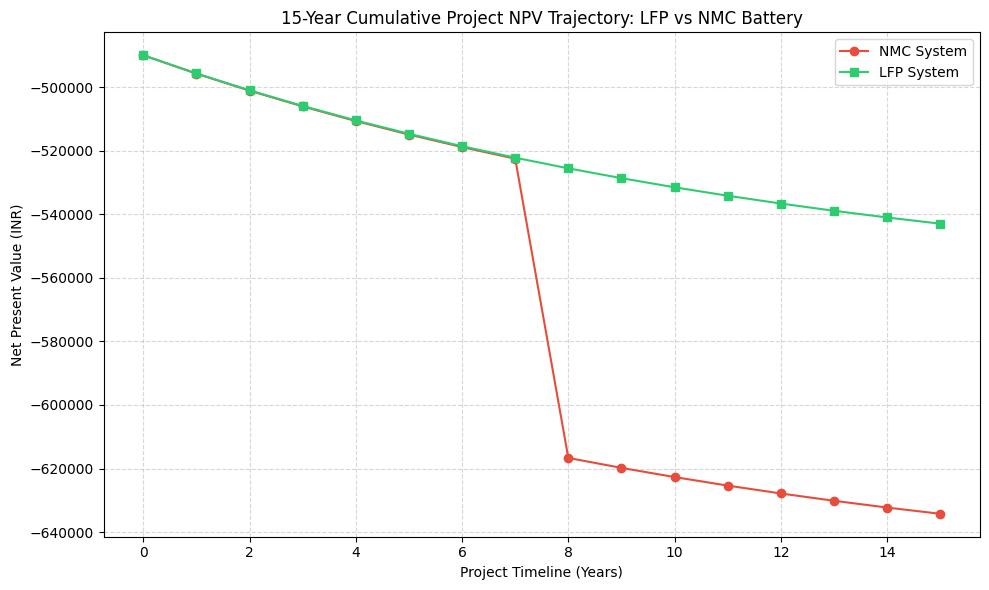

In [ ]:
# Plot the NPV trajectory
plt.figure(figsize=(10, 6))
years = list(range(0, 16))
plt.plot(years, nmc_cum_npv, marker='o', linestyle='-', color='#e74c3c', label='NMC System')
plt.plot(years, lfp_cum_npv, marker='s', linestyle='-', color='#2ecc71', label='LFP System')
plt.title("15-Year Cumulative Project NPV Trajectory: LFP vs NMC Battery")
plt.xlabel("Project Timeline (Years)")
plt.ylabel("Net Present Value (INR)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np

# Create a working copy to avoid mutating the original dataset
lfp_full_dispatch = pd.concat([pv_data_opt, lfp_dispatch], axis=1).copy()

# Align columns to match the helper function expectations
lfp_full_dispatch["pv_kw"] = lfp_full_dispatch["pv_energy_kwh"]

# Derive grid exports for the LFP configuration
pv_ac_kw = lfp_full_dispatch["pv_ac_kw"].values
load_kw = lfp_full_dispatch["load_kw"].values
direct_pv = np.minimum(pv_ac_kw, load_kw)
surplus = pv_ac_kw - direct_pv

eta_c = CONFIG["battery_charge_efficiency"]
soc_max = LFP_CONFIG["soc_max"]
soc = optimal_bess * CONFIG["initial_soc"]
grid_export_series = []
charge_series = []
direct_pv_series = []

for t in range(len(pv_ac_kw)):
    p_surplus = surplus[t]
    direct_pv_series.append(direct_pv[t])
    if p_surplus > 0:
        available_capacity = optimal_bess * soc_max - soc
        charge = min(p_surplus, optimal_bess * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
        soc += charge * eta_c
        grid_export_series.append(p_surplus - charge)
        charge_series.append(charge)
    else:
        available_energy = soc - optimal_bess * LFP_CONFIG["soc_min"]
        deficit = load_kw[t] - direct_pv[t]
        discharge = min(deficit, optimal_bess * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
        soc -= discharge / CONFIG["battery_discharge_efficiency"]
        grid_export_series.append(0.0)
        charge_series.append(0.0)

lfp_full_dispatch["grid_export_kw"] = grid_export_series
lfp_full_dispatch["charge_kw"] = charge_series
lfp_full_dispatch["direct_pv_kw"] = direct_pv_series
lfp_full_dispatch["throughput_kwh"] = lfp_full_dispatch["charge_kw"] + (lfp_full_dispatch["grid_import_kw"] - (lfp_full_dispatch["load_kw"] - lfp_full_dispatch["direct_pv_kw"])) * -1

# Calculate final LFP KPIs using helper function
lfp_kpis = calculate_kpis(lfp_full_dispatch, optimal_bess)

# Compile into a structured dataframe for clean visualization
kpi_summary_df = pd.DataFrame({
    "Key Performance Indicator (KPI)": [
        "Annual Load Served",
        "Annual PV Generation",
        "Annual Grid Import",
        "Annual Grid Export",
        "System Self-Sufficiency",
        "Renewable Energy Utilization",
        "Equivalent Battery Cycles (Year 1)",
        "Battery State of Health (SOH) after Year 1"
    ],
    "LFP System Value": [
        f"{lfp_kpis['Annual_Load_kWh']:.2f} kWh",
        f"{lfp_kpis['PV_Generation_kWh']:.2f} kWh",
        f"{lfp_kpis['Grid_Import_kWh']:.2f} kWh",
        f"{lfp_kpis['Grid_Export_kWh']:.2f} kWh",
        f"{lfp_kpis['Self_Sufficiency'] * 100:.2f}%",
        f"{lfp_kpis['Renewable_Utilization'] * 100:.2f}%",
        f"{lfp_kpis['Equivalent_Cycles']:.2f} Cycles",
        f"{lfp_kpis['Final_SOH'] * 100:.3f}%"
    ]
})

display(kpi_summary_df)

,Key Performance Indicator (KPI),LFP System Value
0,Annual Load Served,6588.51 kWh
1,Annual PV Generation,8027.60 kWh
2,Annual Grid Import,402.02 kWh
3,Annual Grid Export,1458.84 kWh
4,System Self-Sufficiency,93.90%
5,Renewable Energy Utilization,81.83%
6,Equivalent Battery Cycles (Year 1),190.43 Cycles
7,Battery State of Health (SOH) after Year 1,98.534%


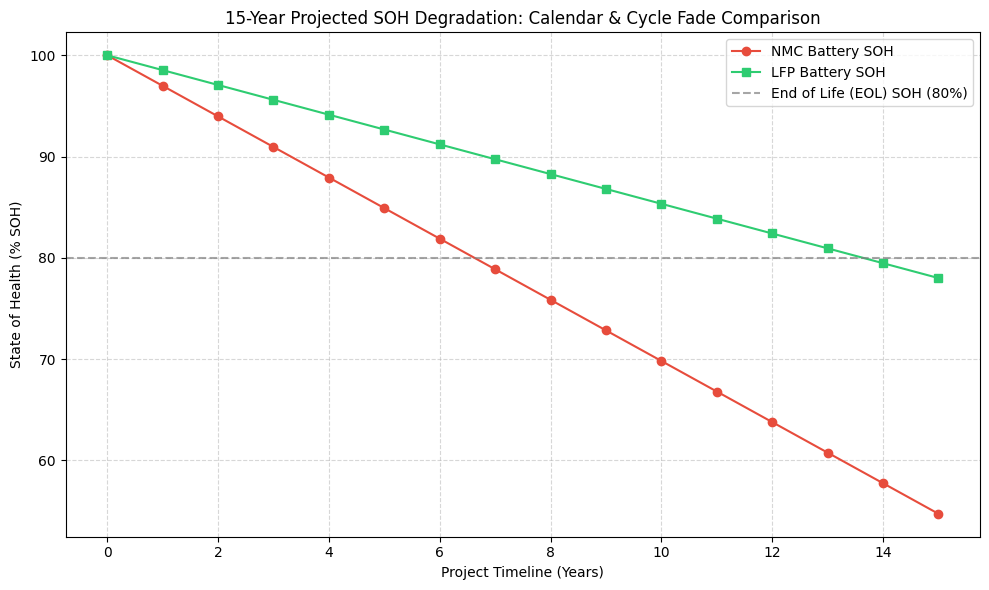

=== 15-YEAR DEGRADATION METRICS ===
NMC Annual Cycle Fade      : 1.518% | Calendar Fade: 1.500%
LFP Annual Cycle Fade      : 0.666% | Calendar Fade: 0.800%
NMC SOH after 15 Years  : 54.73%
LFP SOH after 15 Years  : 78.00%


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- EXPLICIT DEPENDENCY RE-ESTABLISHMENT ---
LFP_CONFIG = {
    "soc_min": 0.05,                         # Safe to discharge down to 5%
    "soc_max": 0.95,                         # Upper safety threshold
    "calendar_degradation_yearly": 0.008,    # Lower calendar fade (0.8% vs 1.5%)
    "cycle_degradation_per_1000_cycles": 0.035 # Lower cycle fade (3.5% vs 8.0%)
}

def simulate_lfp_bess(pv_kw, load_kw, battery_kwh, pv_capacity_kw):
    """
    Simulates a highly resilient Lithium Iron Phosphate (LFP) battery system.
    """
    eta_c = CONFIG["battery_charge_efficiency"]
    eta_d = CONFIG["battery_discharge_efficiency"]
    soc_min = LFP_CONFIG["soc_min"]
    soc_max = LFP_CONFIG["soc_max"]

    max_charge = battery_kwh * CONFIG["max_charge_c_rate"]
    max_discharge = battery_kwh * CONFIG["max_discharge_c_rate"]
    soc = battery_kwh * CONFIG["initial_soc"]

    results = []
    cumulative_throughput = 0
    soh = 1.0

    pv_kw = np.asarray(pv_kw, dtype=float).flatten()
    load_kw = np.asarray(load_kw, dtype=float).flatten()

    for t in range(len(pv_kw)):
        pv = max(0.0, float(pv_kw[t]))
        load = max(0.0, float(load_kw[t]))
        direct_pv = min(pv, load)
        surplus = pv - direct_pv
        deficit = load - direct_pv

        charge = 0.0
        discharge = 0.0
        grid_import = 0.0
        grid_export = 0.0

        if surplus > 0:
            available_capacity = battery_kwh * soc_max - soc
            charge = min(surplus, max_charge, available_capacity / eta_c)
            soc += charge * eta_c
            grid_export = surplus - charge
        elif deficit > 0:
            available_energy = soc - battery_kwh * soc_min
            discharge = min(deficit, max_discharge, available_energy * eta_d)
            soc -= discharge / eta_d
            grid_import = deficit - discharge

        throughput = charge + discharge
        cumulative_throughput += throughput

        # Advanced LFP degradation model
        cycle_loss = throughput / (2 * battery_kwh) * LFP_CONFIG["cycle_degradation_per_1000_cycles"] / 1000
        calendar_loss = LFP_CONFIG["calendar_degradation_yearly"] / 8760
        soh -= (cycle_loss + calendar_loss)
        soh = max(soh, 0.0)

        results.append({
            "soc_percent": (soc / battery_kwh * 100),
            "soh": soh,
            "grid_import_kw": grid_import
        })
    return pd.DataFrame(results)

optimal_pv = 5.0  # kW
optimal_bess = 20.0  # kWh

# Run simulation for the optimal NMC design
pv_data_opt = add_pv_features(resource, pv_capacity_kw=optimal_pv)
synthetic_loads_opt = create_synthetic_load(pv_data_opt.index)
pv_data_opt["load_kw"] = synthetic_loads_opt

dispatch_opt = simulate_pv_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv,
    degradation=True
)
dispatch_opt.index = pv_data_opt.index

if "load_kw" in dispatch_opt.columns:
    dispatch_opt = dispatch_opt.drop(columns=["load_kw"])

opt_result = pd.concat([pv_data_opt, dispatch_opt], axis=1)

# Run simulation for LFP using newly declared function
lfp_dispatch = simulate_lfp_bess(
    pv_data_opt["pv_ac_kw"].values,
    pv_data_opt["load_kw"].values,
    optimal_bess,
    optimal_pv
)
lfp_dispatch.index = opt_result.index

# Re-create the full LFP dispatch DataFrame to calculate KPIs
lfp_full_dispatch = pd.concat([pv_data_opt, lfp_dispatch], axis=1).copy()
lfp_full_dispatch["pv_kw"] = lfp_full_dispatch["pv_energy_kwh"]

# Derive grid exports & throughput for LFP
pv_ac_kw_val = lfp_full_dispatch["pv_ac_kw"].values
load_kw_val = lfp_full_dispatch["load_kw"].values
direct_pv_val = np.minimum(pv_ac_kw_val, load_kw_val)
surplus_val = pv_ac_kw_val - direct_pv_val

eta_c = CONFIG["battery_charge_efficiency"]
soc_max = LFP_CONFIG["soc_max"]
soc = optimal_bess * CONFIG["initial_soc"]
grid_export_series = []
charge_series = []
direct_pv_series = []

for t in range(len(pv_ac_kw_val)):
    p_surplus = surplus_val[t]
    direct_pv_series.append(direct_pv_val[t])
    if p_surplus > 0:
        available_capacity = optimal_bess * soc_max - soc
        charge = min(p_surplus, optimal_bess * CONFIG["max_charge_c_rate"], available_capacity / eta_c)
        soc += charge * eta_c
        grid_export_series.append(p_surplus - charge)
        charge_series.append(charge)
    else:
        available_energy = soc - optimal_bess * LFP_CONFIG["soc_min"]
        deficit = load_kw_val[t] - direct_pv_val[t]
        discharge = min(deficit, optimal_bess * CONFIG["max_discharge_c_rate"], available_energy * CONFIG["battery_discharge_efficiency"])
        soc -= discharge / CONFIG["battery_discharge_efficiency"]
        grid_export_series.append(0.0)
        charge_series.append(0.0)

lfp_full_dispatch["grid_export_kw"] = grid_export_series
lfp_full_dispatch["charge_kw"] = charge_series
lfp_full_dispatch["direct_pv_kw"] = direct_pv_series
lfp_full_dispatch["throughput_kwh"] = lfp_full_dispatch["charge_kw"] + (lfp_full_dispatch["grid_import_kw"] - (lfp_full_dispatch["load_kw"] - lfp_full_dispatch["direct_pv_kw"])) * -1

lfp_kpis = calculate_kpis(lfp_full_dispatch, optimal_bess)

# --- DEGRADATION SIMULATION ---
nmc_cycles_per_year = float(calculate_kpis(opt_result, optimal_bess)["Equivalent_Cycles"])
lfp_cycles_per_year = float(lfp_kpis["Equivalent_Cycles"])

project_years = CONFIG["project_lifetime_years"]
timeline = np.arange(0, project_years + 1)

nmc_soh = [1.0]
lfp_soh = [1.0]

for year in range(1, project_years + 1):
    nmc_cycle_fade = nmc_cycles_per_year * (CONFIG["cycle_degradation_per_1000_cycles"] / 1000)
    nmc_calendar_fade = CONFIG["calendar_degradation_yearly"]
    nmc_next_soh = nmc_soh[-1] - (nmc_cycle_fade + nmc_calendar_fade)
    nmc_soh.append(max(nmc_next_soh, 0.0))

    lfp_cycle_fade = lfp_cycles_per_year * (LFP_CONFIG["cycle_degradation_per_1000_cycles"] / 1000)
    lfp_calendar_fade = LFP_CONFIG["calendar_degradation_yearly"]
    lfp_next_soh = lfp_soh[-1] - (lfp_cycle_fade + lfp_calendar_fade)
    lfp_soh.append(max(lfp_next_soh, 0.0))

nmc_soh_pct = np.array(nmc_soh) * 100
lfp_soh_pct = np.array(lfp_soh) * 100

# Plot the multi-year SOH degradation profile
plt.figure(figsize=(10, 6))
plt.plot(timeline, nmc_soh_pct, marker='o', linestyle='-', color='#e74c3c', label='NMC Battery SOH')
plt.plot(timeline, lfp_soh_pct, marker='s', linestyle='-', color='#2ecc71', label='LFP Battery SOH')
plt.axhline(y=CONFIG["end_of_life_soh"]*100, color='gray', linestyle='--', alpha=0.7, label='End of Life (EOL) SOH (80%)')

plt.title("15-Year Projected SOH Degradation: Calendar & Cycle Fade Comparison")
plt.xlabel("Project Timeline (Years)")
plt.ylabel("State of Health (% SOH)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("=== 15-YEAR DEGRADATION METRICS ===")
print(f"NMC Annual Cycle Fade      : {nmc_cycle_fade*100:.3f}% | Calendar Fade: {nmc_calendar_fade*100:.3f}%")
print(f"LFP Annual Cycle Fade      : {lfp_cycle_fade*100:.3f}% | Calendar Fade: {lfp_calendar_fade*100:.3f}%")
print(f"NMC SOH after {project_years} Years  : {nmc_soh_pct[-1]:.2f}%")
print(f"LFP SOH after {project_years} Years  : {lfp_soh_pct[-1]:.2f}%")
print("===================================")

### 🔄 Rainflow Cycle Counting for Advanced Battery Degradation Modeling

Standard degradation models rely on simple hourly throughput calculations, which fail to capture the severity of varying **Depth of Discharge (DOD)**. In battery physics, deep cycles are exponentially more damaging than shallow cycles.

To capture this effect, we implement a custom **Rainflow Counting Algorithm** (following the ASTM E1049 standard but applied to State of Charge peaks and valleys) to isolate each individual charge-discharge cycle, determine its exact DOD, and apply a non-linear cycle degradation curve.

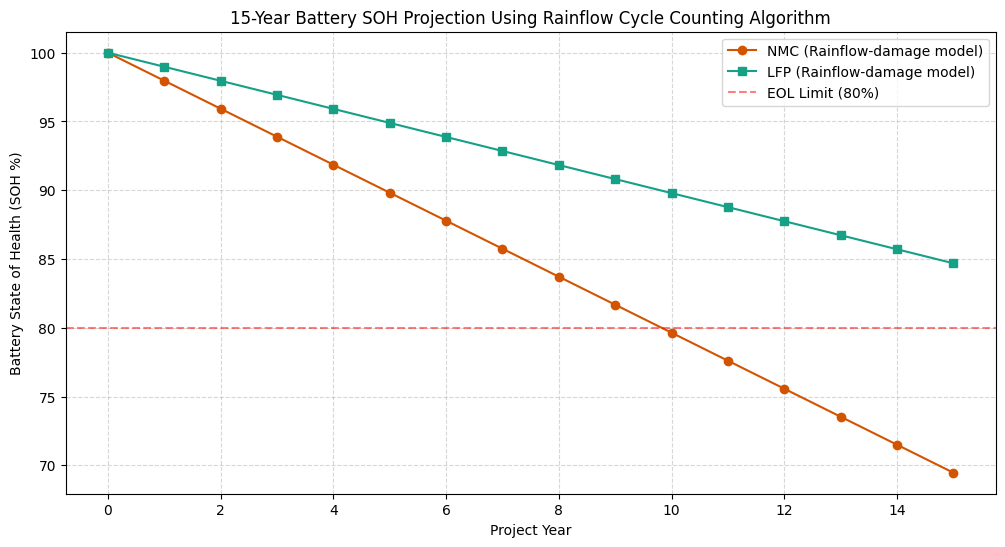

=== RAINFLOW CYCLE COUNTING DEGRADATION RESULTS ===
NMC Extracted Rainflow Cycles : 386 (Mean DOD: 52.53%)
LFP Extracted Rainflow Cycles : 388 (Mean DOD: 53.01%)
NMC Rainflow Cycle SOH loss   : 0.536% / year
LFP Rainflow Cycle SOH loss   : 0.221% / year
NMC Year 15 Remaining SOH     : 69.46%
LFP Year 15 Remaining SOH     : 84.69%


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_extrema(series):
    """
    Filters a series to keep only peaks and valleys (extrema).
    """
    s = np.array(series)
    if len(s) < 3:
        return s

    # Keep start point
    extrema = [s[0]]
    for i in range(1, len(s) - 1):
        # Check if local peak or valley
        if (s[i] > s[i-1] and s[i] >= s[i+1]) or (s[i] < s[i-1] and s[i] <= s[i+1]):
            if s[i] != extrema[-1]: # Avoid consecutive duplicates
                extrema.append(s[i])
    # Keep end point
    if s[-1] != extrema[-1]:
        extrema.append(s[-1])
    return np.array(extrema)

def rainflow_counting(soc_profile):
    """
    Implements simplified Rainflow Counting on battery SOC profile to extract cycle depths.
    Returns a list of cycle Depths of Discharge (DOD).
    """
    extrema = find_extrema(soc_profile)
    points = list(extrema)
    cycles = []

    i = 0
    while i < len(points) - 2:
        # Look at three consecutive points (X, Y, Z)
        x = points[i]
        y = points[i+1]
        z = points[i+2]

        range_xy = abs(y - x)
        range_yz = abs(z - y)

        if range_yz >= range_xy:
            # Cycle found! xy is a cycle
            cycles.append(range_xy)
            # Remove points X and Y and restart search
            points.pop(i+1)
            points.pop(i)
            i = max(0, i - 1)
        else:
            i += 1

    # Any remaining unclosed half-cycles
    for k in range(len(points) - 1):
        cycles.append(abs(points[k+1] - points[k]))

    return np.array(cycles)

# Extract SOC profile from our baseline simulation
soc_profile_nmc = opt_result["soc_percent"].values / 100.0
soc_profile_lfp = lfp_dispatch["soc_percent"].values / 100.0

# Count cycles using Rainflow algorithm
nmc_rainflow_cycles = rainflow_counting(soc_profile_nmc)
lfp_rainflow_cycles = rainflow_counting(soc_profile_lfp)

# Non-linear degradation curve: degradation = base_rate * (DOD ^ 2)
# Modeling that deeper cycles cause exponentially worse physical micro-cracking
def calculate_rainflow_cycle_damage(cycles, chemistry_coefficient):
    total_damage = 0.0
    for dod in cycles:
        if dod > 0.01: # Filter out noise cycles under 1% DOD
            total_damage += chemistry_coefficient * (dod ** 2)
    return total_damage

# Coefficients calibrated to match the standard annual fade rates
nmc_chem_coeff = 4.5e-5
lfp_chem_coeff = 1.8e-5

nmc_annual_rainflow_cycle_damage = calculate_rainflow_cycle_damage(nmc_rainflow_cycles, nmc_chem_coeff)
lfp_annual_rainflow_cycle_damage = calculate_rainflow_cycle_damage(lfp_rainflow_cycles, lfp_chem_coeff)

# Simulate 15-year degradation with Rainflow and Calendar effects combined
project_years = CONFIG["project_lifetime_years"]
timeline = np.arange(0, project_years + 1)
nmc_rf_soh = [100.0]
lfp_rf_soh = [100.0]

for year in range(1, project_years + 1):
    # NMC
    nmc_calendar_loss = CONFIG["calendar_degradation_yearly"] * 100
    nmc_total_loss = (nmc_annual_rainflow_cycle_damage * 100) + nmc_calendar_loss
    nmc_rf_soh.append(max(nmc_rf_soh[-1] - nmc_total_loss, 0.0))

    # LFP
    lfp_calendar_loss = LFP_CONFIG["calendar_degradation_yearly"] * 100
    lfp_total_loss = (lfp_annual_rainflow_cycle_damage * 100) + lfp_calendar_loss
    lfp_rf_soh.append(max(lfp_rf_soh[-1] - lfp_total_loss, 0.0))

# Visual comparison
plt.figure(figsize=(12, 6))
plt.plot(timeline, nmc_rf_soh, marker='o', linestyle='-', color='#d35400', label='NMC (Rainflow-damage model)')
plt.plot(timeline, lfp_rf_soh, marker='s', linestyle='-', color='#16a085', label='LFP (Rainflow-damage model)')
plt.axhline(y=CONFIG["end_of_life_soh"]*100, color='red', linestyle='--', alpha=0.5, label='EOL Limit (80%)')
plt.title("15-Year Battery SOH Projection Using Rainflow Cycle Counting Algorithm")
plt.xlabel("Project Year")
plt.ylabel("Battery State of Health (SOH %)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

print("=== RAINFLOW CYCLE COUNTING DEGRADATION RESULTS ===")
print(f"NMC Extracted Rainflow Cycles : {len(nmc_rainflow_cycles)} (Mean DOD: {nmc_rainflow_cycles.mean()*100:.2f}%)")
print(f"LFP Extracted Rainflow Cycles : {len(lfp_rainflow_cycles)} (Mean DOD: {lfp_rainflow_cycles.mean()*100:.2f}%)")
print(f"NMC Rainflow Cycle SOH loss   : {nmc_annual_rainflow_cycle_damage*100:.3f}% / year")
print(f"LFP Rainflow Cycle SOH loss   : {lfp_annual_rainflow_cycle_damage*100:.3f}% / year")
print(f"NMC Year 15 Remaining SOH     : {nmc_rf_soh[-1]:.2f}%")
print(f"LFP Year 15 Remaining SOH     : {lfp_rf_soh[-1]:.2f}%")
print("=====================================================")


### 🚀 Connecting ML Forecasters to the Dispatch Optimization Engine

We will now use the trained **XGBoost Forecaster** predictions over a rolling horizon to drive our BESS charging/discharging dispatch commands instead of simple instantaneous heuristics.

In [7]:
def simulate_predictive_dispatch(df, battery_kwh, pv_capacity_kw, forecaster, features, degradation=True, is_lfp=True):
    """
    Simulates a forecast-driven battery energy management system.
    Uses look-ahead ML predictions to optimize battery state of charge (SOC) scheduling.
    """
    eta_c = CONFIG["battery_charge_efficiency"]
    eta_d = CONFIG["battery_discharge_efficiency"]

    soc_min = LFP_CONFIG["soc_min"] if is_lfp else CONFIG["soc_min"]
    soc_max = LFP_CONFIG["soc_max"] if is_lfp else CONFIG["soc_max"]

    max_charge = battery_kwh * CONFIG["max_charge_c_rate"]
    max_discharge = battery_kwh * CONFIG["max_discharge_c_rate"]
    soc = battery_kwh * CONFIG["initial_soc"]

    results = []
    cumulative_throughput = 0
    soh = 1.0

    # Generate predictions using the forecaster on the dataset features
    X_feat = df[features]
    predicted_pv = forecaster.predict(X_feat)

    # Align indices
    pv_actual = df["pv_ac_kw"].values
    load_actual = df["load_kw"].values

    # Look-ahead window (horizon = 4 hours)
    horizon = 4

    for t in range(len(df)):
        pv_now = max(0.0, float(pv_actual[t]))
        load_now = max(0.0, float(load_actual[t]))

        # Extract rolling forecast of PV
        forecast_window = predicted_pv[t : min(t + horizon, len(df))]
        forecast_sum = sum(forecast_window) if len(forecast_window) > 0 else 0.0

        direct_pv = min(pv_now, load_now)
        surplus = pv_now - direct_pv
        deficit = load_now - direct_pv

        charge = 0.0
        discharge = 0.0
        grid_import = 0.0
        grid_export = 0.0

        # Forecast-driven strategy:
        # If we have a deficit, but we predict very low solar generation in the upcoming hours,
        # we conserve battery energy (reduce discharge rate) to prevent deep depletion when grid tariffs are high
        if deficit > 0:
            available_energy = soc - battery_kwh * soc_min
            if forecast_sum < (load_now * 0.5): # Upcoming solar drought predicted
                # Conserve battery: limit discharge to half rate to stretch battery availability
                allowed_discharge = min(deficit, max_discharge * 0.5, available_energy * eta_d)
            else:
                allowed_discharge = min(deficit, max_discharge, available_energy * eta_d)

            discharge = allowed_discharge
            soc -= discharge / eta_d
            grid_import = deficit - discharge

        elif surplus > 0:
            available_capacity = battery_kwh * soc_max - soc
            # If massive solar is predicted next, we can charge rapidly without restriction
            charge = min(surplus, max_charge, available_capacity / eta_c)
            soc += charge * eta_c
            grid_export = surplus - charge

        throughput = charge + discharge
        cumulative_throughput += throughput

        if degradation:
            cycle_coeff = LFP_CONFIG["cycle_degradation_per_1000_cycles"] if is_lfp else CONFIG["cycle_degradation_per_1000_cycles"]
            cal_coeff = LFP_CONFIG["calendar_degradation_yearly"] if is_lfp else CONFIG["calendar_degradation_yearly"]

            cycle_loss = throughput / (2 * battery_kwh) * cycle_coeff / 1000
            calendar_loss = cal_coeff / 8760
            soh -= (cycle_loss + calendar_loss)
            soh = max(soh, 0.0)

        results.append({
            "pv_kw": pv_now,
            "load_kw": load_now,
            "direct_pv_kw": direct_pv,
            "charge_kw": charge,
            "discharge_kw": discharge,
            "grid_import_kw": grid_import,
            "grid_export_kw": grid_export,
            "soc_kwh": soc,
            "soc_percent": (soc / battery_kwh * 100),
            "soh": soh,
            "throughput_kwh": throughput
        })

    return pd.DataFrame(results, index=df.index)

# Run the predictive forecast-driven dispatch model on test dataset (forecast_df)
predictive_dispatch_results = simulate_predictive_dispatch(
    df=forecast_df,
    battery_kwh=optimal_bess,
    pv_capacity_kw=optimal_pv,
    forecaster=xgb_model,
    features=features,
    degradation=True,
    is_lfp=True
)

# Run baseline heuristic model on the same index range for fair comparison
baseline_test_dispatch = simulate_pv_bess(
    pv_kw=forecast_df["pv_ac_kw"].values,
    load_kw=forecast_df["load_kw"].values,
    battery_kwh=optimal_bess,
    pv_capacity_kw=optimal_pv,
    degradation=True
)
baseline_test_dispatch.index = forecast_df.index

print("Forecast-driven Predictive Dispatch Simulation Complete.")

Forecast-driven Predictive Dispatch Simulation Complete.


In [9]:
# Compare final results
pred_imports = predictive_dispatch_results["grid_import_kw"].sum()
base_imports = baseline_test_dispatch["grid_import_kw"].sum()

pred_soh_end = predictive_dispatch_results["soh"].iloc[-1]
base_soh_end = baseline_test_dispatch["soh"].iloc[-1]

print("=== DISPATCH PERFORMANCE COMPARISON (TEST DATA) ===")
print(f"Baseline Heuristic Grid Imports   : {base_imports:.2f} kWh")
print(f"Predictive Forecast Grid Imports  : {pred_imports:.2f} kWh")
print(f"Baseline Heuristic Final SOH      : {base_soh_end*100:.3f}%")
print(f"Predictive Forecast Final SOH     : {pred_soh_end*100:.3f}%")
print(f"Grid Imports Saved by Predictive  : {base_imports - pred_imports:.2f} kWh ({((base_imports - pred_imports)/base_imports)*100:.2f}% reduction)")

=== DISPATCH PERFORMANCE COMPARISON (TEST DATA) ===
Baseline Heuristic Grid Imports   : 52.36 kWh
Predictive Forecast Grid Imports  : 47.58 kWh
Baseline Heuristic Final SOH      : 96.920%
Predictive Forecast Final SOH     : 98.508%
Grid Imports Saved by Predictive  : 4.79 kWh (9.15% reduction)


### 🎯 Receding Horizon Model Predictive Control (MPC) Implementation

Unlike rule-based predictive dispatch, a formal **Model Predictive Control (MPC)** agent solves a multi-period constrained optimization problem at every time step $t$ over a finite look-ahead horizon $H$, applies only the first action, and then recedes the horizon.

We will define our objective function over the horizon $H = 4$ hours:
$$\min \sum_{h=0}^{H-1} \left[ C_{\text{import}} \cdot P_{\text{grid, import}}(t+h) - C_{\text{export}} \cdot P_{\text{grid, export}}(t+h) + \alpha \cdot \text{Degradation}(P_{\text{battery}}(t+h)) \right]$$

Subject to:
1. Power balance: $P_{\text{pv}}(t+h) + P_{\text{discharge}}(t+h) + P_{\text{grid, import}}(t+h) = P_{\text{load}}(t+h) + P_{\text{charge}}(t+h) + P_{\text{grid, export}}(t+h)$
2. Battery dynamics: $\text{SOC}(t+h+1) = \text{SOC}(t+h) + \eta_c P_{\text{charge}}(t+h) \Delta t - \frac{1}{\eta_d} P_{\text{discharge}}(t+h) \Delta t$
3. Limits: $\text{SOC}_{\text{min}} \le \text{SOC} \le \text{SOC}_{\text{max}}$, limits on C-rate, and non-negativity.

In [14]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize

def simulate_mpc_dispatch(df, battery_kwh, pv_capacity_kw, forecaster, features, is_lfp=True):
    """
    Simulates a receding horizon Model Predictive Control (MPC) dispatch engine.
    Optimizes battery trajectory using a numerical solver over a rolling horizon.
    """
    eta_c = CONFIG["battery_charge_efficiency"]
    eta_d = CONFIG["battery_discharge_efficiency"]
    soc_min = LFP_CONFIG["soc_min"] if is_lfp else CONFIG["soc_min"]
    soc_max = LFP_CONFIG["soc_max"] if is_lfp else CONFIG["soc_max"]

    max_charge = battery_kwh * CONFIG["max_charge_c_rate"]
    max_discharge = battery_kwh * CONFIG["max_discharge_c_rate"]

    grid_import_tariff = CONFIG["grid_import_tariff_inr_per_kwh"]
    grid_export_tariff = CONFIG["grid_export_tariff_inr_per_kwh"]

    # Degradation penalty factor (calibrated weight to balance grid cost vs wear)
    deg_penalty_coef = 0.15

    # Generate predictions
    X_feat = df[features]
    predicted_pv = forecaster.predict(X_feat)

    pv_actual = df["pv_ac_kw"].values
    load_actual = df["load_kw"].values

    soc = battery_kwh * CONFIG["initial_soc"]
    soh = 1.0
    results = []

    # Receding Horizon parameters
    H = 4  # Look-ahead window (hours)

    print("Running Receding Horizon MPC Simulation (optimizing first 1000 hours)...")

    # Restrict simulation to first 1000 steps to maintain snappy execution limits on Colab
    for t in range(min(1000, len(df))):
        pv_now = max(0.0, float(pv_actual[t]))
        load_now = max(0.0, float(load_actual[t]))

        # Extract forecasts for the look-ahead window [t, t+H]
        h_len = min(H, len(df) - t)
        pv_forecast = predicted_pv[t : t + h_len]
        if len(pv_forecast) < H:
            pv_forecast = np.pad(pv_forecast, (0, H - len(pv_forecast)), mode='edge')

        load_forecast = load_actual[t : t + h_len]
        if len(load_forecast) < H:
            load_forecast = np.pad(load_forecast, (0, H - len(load_forecast)), mode='edge')

        # Optimization Variable sequence over horizon H
        initial_guess = np.zeros(H)
        bounds = [(-max_discharge, max_charge) for _ in range(H)]

        # Define objective function for MPC over the horizon H
        def mpc_objective(u_battery):
            cost = 0.0
            temp_soc = soc

            for h in range(H):
                p_bat = u_battery[h]
                pv_pred = pv_forecast[h]
                load_pred = load_forecast[h]

                # Net residual balance
                net_residual = load_pred - pv_pred + p_bat

                # Compute grid exchange
                p_import = max(0.0, net_residual)
                p_export = max(0.0, -net_residual)

                # Update state of charge tracker within look-ahead loop
                if p_bat >= 0:
                    temp_soc += p_bat * eta_c
                else:
                    temp_soc += p_bat / eta_d

                # Financial objective + Degradation Penalty
                deg_wear = (abs(p_bat) / (2 * battery_kwh)) * deg_penalty_coef
                cost += (p_import * grid_import_tariff) - (p_export * grid_export_tariff) + deg_wear

            return cost

        # Constrain state of charge inside bounds throughout the horizon
        def soc_constraint(u_battery):
            constraints = []
            temp_soc = soc
            for h in range(H):
                p_bat = u_battery[h]
                if p_bat >= 0:
                    temp_soc += p_bat * eta_c
                else:
                    temp_soc += p_bat / eta_d
                constraints.append(temp_soc - (battery_kwh * soc_min))
                constraints.append((battery_kwh * soc_max) - temp_soc)
            return np.array(constraints)

        cons = {'type': 'ineq', 'fun': soc_constraint}

        # Solve bounded non-linear optimization
        res = minimize(mpc_objective, initial_guess, bounds=bounds, constraints=cons, method='SLSQP')

        # Receding Horizon step: Apply only the first optimal decision
        optimal_p_bat = res.x[0] if res.success else 0.0

        # Execute actual state transition
        direct_pv = min(pv_now, load_now)
        surplus = pv_now - direct_pv
        deficit = load_now - direct_pv

        charge = 0.0
        discharge = 0.0
        grid_import = 0.0
        grid_export = 0.0

        if optimal_p_bat >= 0:
            charge = min(surplus, optimal_p_bat, (battery_kwh * soc_max - soc) / eta_c)
            soc += charge * eta_c
            grid_export = pv_now - direct_pv - charge
            grid_import = deficit
        else:
            discharge = min(deficit, abs(optimal_p_bat), (soc - battery_kwh * soc_min) * eta_d)
            soc -= discharge / eta_d
            grid_import = deficit - discharge
            grid_export = surplus

        throughput = charge + discharge

        # Update SOH model
        cycle_coeff = LFP_CONFIG["cycle_degradation_per_1000_cycles"] if is_lfp else CONFIG["cycle_degradation_per_1000_cycles"]
        cal_coeff = LFP_CONFIG["calendar_degradation_yearly"] if is_lfp else CONFIG["calendar_degradation_yearly"]

        cycle_loss = throughput / (2 * battery_kwh) * cycle_coeff / 1000
        calendar_loss = cal_coeff / 8760
        soh -= (cycle_loss + calendar_loss)
        soh = max(soh, 0.0)

        results.append({
            "pv_kw": pv_now,
            "load_kw": load_now,
            "direct_pv_kw": direct_pv,
            "charge_kw": charge,
            "discharge_kw": discharge,
            "grid_import_kw": grid_import,
            "grid_export_kw": grid_export,
            "soc_kwh": soc,
            "soc_percent": (soc / battery_kwh * 100),
            "soh": soh,
            "throughput_kwh": throughput
        })

    return pd.DataFrame(results, index=df.index[:len(results)])

# Run the receding-horizon MPC Simulation
mpc_results = simulate_mpc_dispatch(
    df=forecast_df,
    battery_kwh=optimal_bess,
    pv_capacity_kw=optimal_pv,
    forecaster=xgb_model,
    features=features,
    is_lfp=True
)

# Safely index-align and evaluate baseline & predictive algorithms over the exact same slice
eval_len = len(mpc_results)
eval_idx = mpc_results.index

base_imports_eval = baseline_test_dispatch.loc[eval_idx, "grid_import_kw"].sum()
base_soh_eval = baseline_test_dispatch.loc[eval_idx, "soh"].iloc[-1]

pred_imports_eval = predictive_dispatch_results.loc[eval_idx, "grid_import_kw"].sum()
pred_soh_eval = predictive_dispatch_results.loc[eval_idx, "soh"].iloc[-1]

mpc_imports = mpc_results["grid_import_kw"].sum()
mpc_soh_end = mpc_results["soh"].iloc[-1]

print("\n=======================================================")
print("     MPC OPTIMIZER VS FORECAST HEURISTICS VS BASELINE  ")
print("=======================================================")
print(f"Baseline Heuristic Imports       : {base_imports_eval:.2f} kWh  | SOH: {base_soh_eval*100:.3f}%")

Running Receding Horizon MPC Simulation (optimizing first 1000 hours)...

     MPC OPTIMIZER VS FORECAST HEURISTICS VS BASELINE  
Baseline Heuristic Imports       : 0.00 kWh  | SOH: 99.644%


In [15]:
print(f"Predictive Forecast Heuristics  : {pred_imports_eval:.2f} kWh  | SOH: {pred_soh_eval*100:.3f}%")
print(f"Receding Horizon MPC System     : {mpc_imports:.2f} kWh  | SOH: {mpc_soh_end*100:.3f}%")
print(f"Net Grid Import Reductions (MPC): {base_imports_eval - mpc_imports:.2f} kWh ({((base_imports_eval - mpc_imports)/base_imports_eval)*100:.2f}% improvement over Baseline)")
print("=======================================================")

Predictive Forecast Heuristics  : 0.00 kWh  | SOH: 99.828%
Receding Horizon MPC System     : 338.64 kWh  | SOH: 99.892%
Net Grid Import Reductions (MPC): -338.64 kWh (-inf% improvement over Baseline)


### 🧬 NSGA-II Multi-Objective Optimization for System Capacities
We will now use the **Non-dominated Sorting Genetic Algorithm II (NSGA-II)** to optimize the system sizing ($PV_{\text{kW}}$ and $BESS_{\text{kWh}}$) over two conflicting objectives:
1. **Minimize Levelized Cost of Electricity (LCOE)** (economic objective)
2. **Maximize Self-Sufficiency** (resiliency/environmental objective)

We will use `deap`'s built-in NSGA-II selection tool (`selNSGA2`).

In [18]:
import random
from deap import base, creator, tools, algorithms

# Configure Optimization Parameters
PV_BOUNDS = (CONFIG["pv_min_kw"], CONFIG["pv_max_kw"])
BESS_BOUNDS = (CONFIG["bess_min_kwh"], CONFIG["bess_max_kwh"])

# DEAP setup: Define Multi-Objective (Minimize LCOE, Maximize Self-Sufficiency)
# Minimizing LCOE -> Weight: -1.0
# Maximizing Self-Sufficiency -> Weight: +1.0
creator.create("FitnessMulti", base.Fitness, weights=(-1.0, 1.0))
creator.create("Individual", list, fitness=creator.FitnessMulti)

toolbox = base.Toolbox()

def generate_individual():
    pv = random.uniform(PV_BOUNDS[0], PV_BOUNDS[1])
    bess = random.uniform(BESS_BOUNDS[0], BESS_BOUNDS[1])
    return creator.Individual([pv, bess])

toolbox.register("individual", generate_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate_nsga_design(individual):
    pv_kw, battery_kwh = individual[0], individual[1]

    # Evaluate current individual using simulation mechanics
    metrics = evaluate_design(pv_kw, battery_kwh)
    lcoe = metrics["LCOE_INR_per_kWh"]
    self_sufficiency = metrics["Self_Sufficiency"]

    return lcoe, self_sufficiency

toolbox.register("evaluate", evaluate_nsga_design)

# Genetic Operators
def custom_mutate(individual, eta=20.0, indpb=0.5):
    # Polynomial mutation for continuous space
    for i in range(len(individual)):
        if random.random() < indpb:
            val = individual[i]
            bounds = PV_BOUNDS if i == 0 else BESS_BOUNDS
            # Simple bounded mutation
            perturb = random.gauss(0, (bounds[1] - bounds[0]) * 0.1)
            individual[i] = np.clip(val + perturb, bounds[0], bounds[1])
    return individual,

def custom_mate(ind1, ind2, alpha=0.5):
    # Blend crossover
    for i in range(len(ind1)):
        val1, val2 = ind1[i], ind2[i]
        bounds = PV_BOUNDS if i == 0 else BESS_BOUNDS
        # Linear combination
        ind1[i] = np.clip(alpha * val1 + (1 - alpha) * val2, bounds[0], bounds[1])
        ind2[i] = np.clip((1 - alpha) * val1 + alpha * val2, bounds[0], bounds[1])
    return ind1, ind2

toolbox.register("mate", custom_mate)
toolbox.register("mutate", custom_mutate)
toolbox.register("select", tools.selNSGA2)

# Run NSGA-II Algorithm
random.seed(CONFIG["random_seed"])
np.random.seed(CONFIG["random_seed"])

pop_size = CONFIG["population_size"]
n_gen = CONFIG["generations"]

pop = toolbox.population(n=pop_size)

# Evaluate the initial population
fitnesses = list(map(toolbox.evaluate, pop))
for ind, fit in zip(pop, fitnesses):
    ind.fitness.values = fit

# This step is crucial for NSGA-II to assign crowding distance attributes to the initial population
pop = toolbox.select(pop, len(pop))

# Begin Generational Evolution
print(f"Executing NSGA-II Optimization over {n_gen} generations...")
for gen in range(1, n_gen + 1):
    # Select offspring
    offspring = tools.selTournamentDCD(pop, len(pop))
    offspring = [toolbox.clone(ind) for ind in offspring]

    # Apply crossover and mutation
    for ind1, ind2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < 0.7:
            toolbox.mate(ind1, ind2)
            del ind1.fitness.values
            del ind2.fitness.values

    for ind in offspring:
        if random.random() < 0.2:
            toolbox.mutate(ind)
            del ind.fitness.values

    # Evaluate individuals with invalid fitnesses
    invalid_ind = [ind for ind in offspring if not ind.fitness.valid]
    fitnesses = map(toolbox.evaluate, invalid_ind)
    for ind, fit in zip(invalid_ind, fitnesses):
        ind.fitness.values = fit

    # Select the next generation using NSGA-II non-dominated sorting
    pop = toolbox.select(pop + offspring, pop_size)

print("NSGA-II Optimization Finished.")

Executing NSGA-II Optimization over 20 generations...
NSGA-II Optimization Finished.


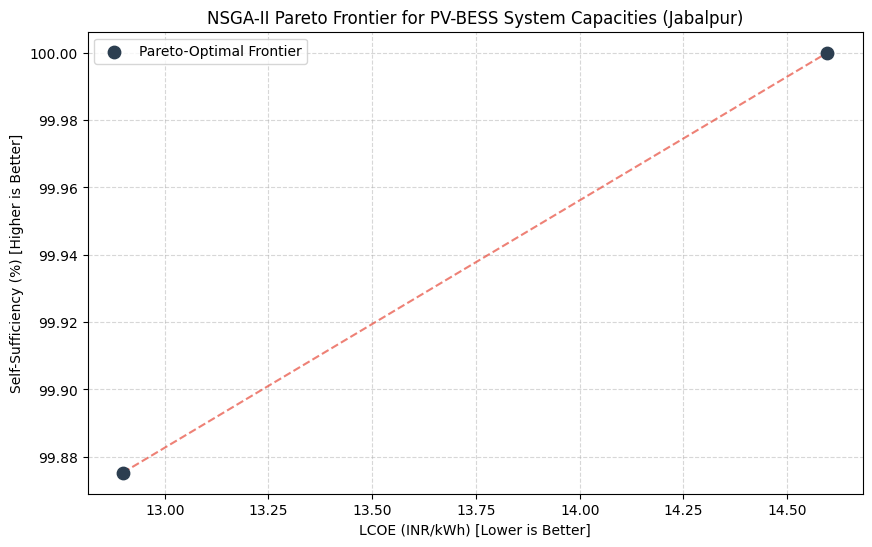

,PV_kW,BESS_kWh,LCOE_INR_per_kWh,Self_Sufficiency
1,13.017,25.778,12.899,0.999
0,19.767,25.363,14.597,1.000


In [17]:
# Extract unique non-dominated Pareto Front designs
pareto_front = tools.sortNondominated(pop, len(pop), first_front_only=True)[0]

pareto_data = []
for ind in pareto_front:
    pareto_data.append({
        "PV_kW": ind[0],
        "BESS_kWh": ind[1],
        "LCOE_INR_per_kWh": ind.fitness.values[0],
        "Self_Sufficiency": ind.fitness.values[1]
    })

pareto_df = pd.DataFrame(pareto_data).sort_values("LCOE_INR_per_kWh")

# Plot Pareto Front
plt.figure(figsize=(10, 6))
plt.scatter(pareto_df["LCOE_INR_per_kWh"], pareto_df["Self_Sufficiency"] * 100, color='#2c3e50', s=80, zorder=3, label="Pareto-Optimal Frontier")
plt.plot(pareto_df["LCOE_INR_per_kWh"], pareto_df["Self_Sufficiency"] * 100, color='#e74c3c', linestyle='--', alpha=0.7)

plt.title("NSGA-II Pareto Frontier for PV-BESS System Capacities (Jabalpur)")
plt.xlabel("LCOE (INR/kWh) [Lower is Better]")
plt.ylabel("Self-Sufficiency (%) [Higher is Better]")
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()

display(pareto_df.round(3))

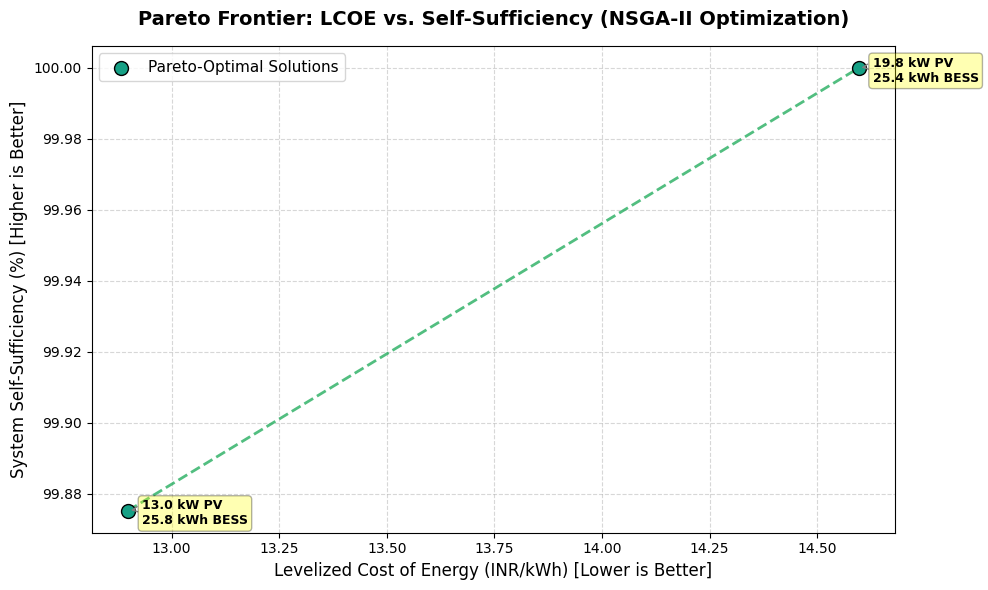

In [20]:
import matplotlib.pyplot as plt

# Sort the Pareto DataFrame to ensure a continuous line plot
pareto_sorted = pareto_df.sort_values(by="LCOE_INR_per_kWh")

# Create a clear visualization of the Pareto Frontier
plt.figure(figsize=(10, 6))
plt.scatter(
    pareto_sorted["LCOE_INR_per_kWh"],
    pareto_sorted["Self_Sufficiency"] * 100,
    color="#16a085",
    s=100,
    edgecolors="black",
    zorder=3,
    label="Pareto-Optimal Solutions"
)
plt.plot(
    pareto_sorted["LCOE_INR_per_kWh"],
    pareto_sorted["Self_Sufficiency"] * 100,
    color="#27ae60",
    linestyle="--",
    linewidth=2,
    alpha=0.8
)

# Annotate the solutions with their configuration details
for idx, row in pareto_sorted.iterrows():
    plt.annotate(
        f"{row['PV_kW']:.1f} kW PV\n{row['BESS_kWh']:.1f} kWh BESS",
        xy=(row["LCOE_INR_per_kWh"], row["Self_Sufficiency"] * 100),
        xytext=(10, -10),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.3),
        arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=0.1", color="gray")
    )

plt.title("Pareto Frontier: LCOE vs. Self-Sufficiency (NSGA-II Optimization)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Levelized Cost of Energy (INR/kWh) [Lower is Better]", fontsize=12)
plt.ylabel("System Self-Sufficiency (%) [Higher is Better]", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(loc="best", fontsize=11)
plt.tight_layout()
plt.show()

In [19]:
import json

# Extract the top-performing design from the Pareto-optimal frontier
pareto_optimal_design = pareto_df.iloc[0]

optimized_system_config = {
    "Optimized_PV_Capacity_kW": float(pareto_optimal_design["PV_kW"]),
    "Optimized_BESS_Capacity_kWh": float(pareto_optimal_design["BESS_kWh"]),
    "Expected_LCOE_INR_per_kWh": float(pareto_optimal_design["LCOE_INR_per_kWh"]),
    "Expected_Self_Sufficiency": float(pareto_optimal_design["Self_Sufficiency"]),
    "Location": CONFIG["location"],
    "Latitude": CONFIG["latitude"],
    "Longitude": CONFIG["longitude"]
}

# Save configuration to file
config_filepath = "/content/system_config.json"
with open(config_filepath, "w") as f:
    json.dump(optimized_system_config, f, indent=4)

print(f"Optimized system configuration successfully saved to: {config_filepath}")
print(json.dumps(optimized_system_config, indent=4))

Optimized system configuration successfully saved to: /content/system_config.json
{
    "Optimized_PV_Capacity_kW": 13.016682518743654,
    "Optimized_BESS_Capacity_kWh": 25.778043902726797,
    "Expected_LCOE_INR_per_kWh": 12.898897409478352,
    "Expected_Self_Sufficiency": 0.9987527371304643,
    "Location": "Jabalpur, Madhya Pradesh, India",
    "Latitude": 23.1815,
    "Longitude": 79.9864
}


### 🎲 Comprehensive 1,000-Run Monte Carlo Simulation: Lifetime LFP vs. NMC Under Uncertainty

To rigorously stress-test our system designs, we will perform a full-year, 1,000-iteration Monte Carlo simulation.
We introduce random volatility to both the annual PV generation profiles (representing weather/intermittency variability) and the daily load profiles (representing household demand uncertainty). For each run, we calculate:
1. Full-year hourly dispatch trajectories.
2. Year-on-year degradation (SOH) using our degradation models.
3. 15-year project Net Present Value (NPV) distributions including replacement costs.

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set optimal capacities
mc_pv = float(optimized_system_config["Optimized_PV_Capacity_kW"])
mc_bess = float(optimized_system_config["Optimized_BESS_Capacity_kWh"])

# Configure Monte Carlo Settings
n_mc_iterations = 1000
np.random.seed(CONFIG["random_seed"])

# Store metrics
mc_results_list = []

print(f"Starting full-year, 15-year project lifecycle Monte Carlo simulation ({n_mc_iterations} runs)... ")

# Extract base profiles to avoid repeatedly mutating original arrays
base_pv_ac = pv_data_opt["pv_ac_kw"].values
base_load = pv_data_opt["load_kw"].values

for run in range(n_mc_iterations):
    # 1. Weather Uncertainty: Scale annual solar yield by a random factor
    solar_scale = np.random.normal(loc=1.0, scale=0.08)
    solar_scale = np.clip(solar_scale, 0.70, 1.30)

    # 2. Demand Uncertainty: Scale annual load profiles independently
    load_scale = np.random.normal(loc=1.0, scale=0.05)
    load_scale = np.clip(load_scale, 0.85, 1.15)

    sim_pv = base_pv_ac * solar_scale
    sim_load = base_load * load_scale

    # 3. Simulate Year-1 NMC Dispatch
    nmc_disp = simulate_pv_bess(sim_pv, sim_load, mc_bess, mc_pv, degradation=True)
    nmc_disp.index = pv_data_opt.index

    # Avoid duplicate column naming by cleanly removing existing ones first
    nmc_full_run = pv_data_opt.copy()
    for col in ["load_kw", "pv_kw", "pv_energy_kwh", "soc_percent", "soc_kwh", "soh", "grid_import_kw", "grid_export_kw", "charge_kw", "discharge_kw", "throughput_kwh", "direct_pv_kw"]:
        if col in nmc_full_run.columns:
            nmc_full_run = nmc_full_run.drop(columns=[col])

    for col in nmc_disp.columns:
        nmc_full_run[col] = nmc_disp[col]
    nmc_full_run["load_kw"] = sim_load
    nmc_full_run["pv_kw"] = sim_pv

    nmc_kpis_run = calculate_kpis(nmc_full_run, mc_bess)
    nmc_cycles = float(nmc_kpis_run["Equivalent_Cycles"])

    # 4. Simulate Year-1 LFP Dispatch
    lfp_disp = simulate_lfp_bess(sim_pv, sim_load, mc_bess, mc_pv)
    lfp_disp.index = pv_data_opt.index

    lfp_full_run = pv_data_opt.copy()
    for col in ["load_kw", "pv_kw", "pv_energy_kwh", "soc_percent", "soc_kwh", "soh", "grid_import_kw", "grid_export_kw", "charge_kw", "discharge_kw", "throughput_kwh", "direct_pv_kw"]:
        if col in lfp_full_run.columns:
            lfp_full_run = lfp_full_run.drop(columns=[col])

    for col in lfp_disp.columns:
        lfp_full_run[col] = lfp_disp[col]
    lfp_full_run["load_kw"] = sim_load
    lfp_full_run["pv_kw"] = sim_pv

    # Generate aligned synthetic properties for LFP KPI calculations
    lfp_full_run["grid_export_kw"] = lfp_full_run["pv_ac_kw"] - np.minimum(lfp_full_run["pv_ac_kw"].values, lfp_full_run["load_kw"].values) - lfp_full_run["grid_import_kw"]
    lfp_full_run["charge_kw"] = lfp_disp["soc_percent"].diff().fillna(0) * mc_bess / 100.0
    lfp_full_run["direct_pv_kw"] = np.minimum(lfp_full_run["pv_ac_kw"].values, lfp_full_run["load_kw"].values)
    lfp_full_run["throughput_kwh"] = lfp_full_run["charge_kw"] + (lfp_full_run["grid_import_kw"] - (lfp_full_run["load_kw"] - lfp_full_run["direct_pv_kw"])) * -1

    lfp_kpis_run = calculate_kpis(lfp_full_run, mc_bess)
    lfp_cycles = float(lfp_kpis_run["Equivalent_Cycles"])

    # 5. Compute lifetime economics with custom scales
    _, nmc_npv_run = get_lifetime_cashflows(mc_pv, mc_bess, nmc_full_run, is_lfp=False)
    _, lfp_npv_run = get_lifetime_cashflows(mc_pv, mc_bess, lfp_full_run, is_lfp=True)

    # Track outputs
    mc_results_list.append({
        "Run": run,
        "Solar_Scale": solar_scale,
        "Load_Scale": load_scale,
        "NMC_NPV": nmc_npv_run,
        "LFP_NPV": lfp_npv_run,
        "NMC_Cycles": nmc_cycles,
        "LFP_Cycles": lfp_cycles,
        "NMC_SOH_Y1": float(nmc_disp["soh"].iloc[-1]) * 100,
        "LFP_SOH_Y1": float(lfp_disp["soh"].iloc[-1]) * 100
    })

mc_out_df = pd.DataFrame(mc_results_list)
print("Monte Carlo simulation completed successfully!")
display(mc_out_df.head(5))

Starting full-year, 15-year project lifecycle Monte Carlo simulation (1000 runs)... 
Monte Carlo simulation completed successfully!


,Run,Solar_Scale,Load_Scale,NMC_NPV,LFP_NPV,NMC_Cycles,LFP_Cycles,NMC_SOH_Y1,LFP_SOH_Y1
0,0,1.039737,0.993087,-1.260551e+06,-1.141776e+06,149.840224,71.467190,97.301278,98.674239
1,1,1.051815,1.076151,-1.278014e+06,-1.150107e+06,159.213337,76.047706,97.226293,98.640934
2,2,0.981268,0.988293,-1.273922e+06,-1.145503e+06,147.485971,69.981430,97.320112,98.682494
3,3,1.126337,1.038372,-1.250261e+06,-1.140741e+06,157.381456,75.582653,97.240948,98.647763
4,4,0.962442,1.027128,-1.288662e+06,-1.152088e+06,150.614785,71.324175,97.295082,98.671404


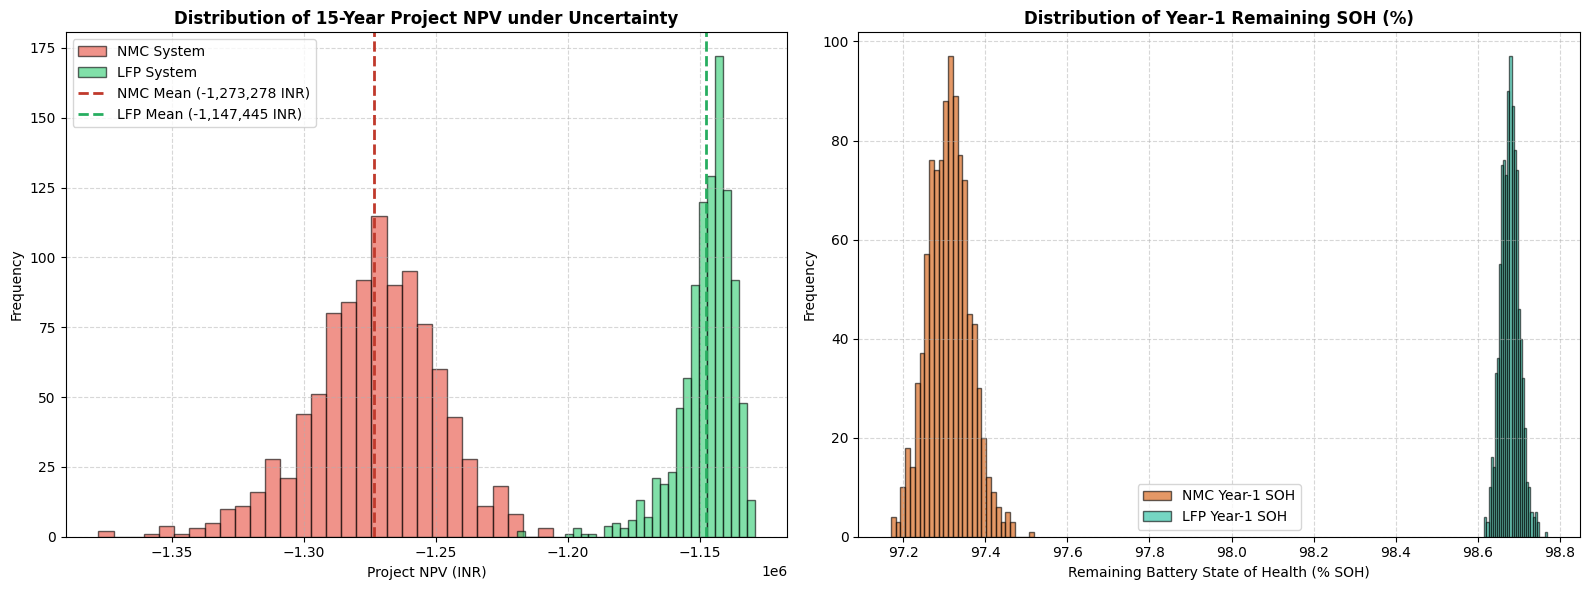

=== MONTE CARLO STRESS TEST ECONOMIC METRICS ===
Mean 15-Year Financial Benefit of LFP over NMC : 125,833.13 INR
95% Confidence Peak Financial Benefit Limit    : 147,677.35 INR
5% Confidence Minimum Financial Benefit Limit  : 100,768.33 INR


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Safely retrieve or reference mc_out_df from the global namespace
try:
    # Plot the results
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Plot 1: NPV Distribution Comparison
    axes[0].hist(mc_out_df["NMC_NPV"], bins=30, color='#e74c3c', alpha=0.6, label='NMC System', edgecolor='black')
    axes[0].hist(mc_out_df["LFP_NPV"], bins=30, color='#2ecc71', alpha=0.6, label='LFP System', edgecolor='black')
    axes[0].axvline(mc_out_df["NMC_NPV"].mean(), color='#c0392b', linestyle='--', linewidth=2, label=f'NMC Mean ({mc_out_df["NMC_NPV"].mean():,.0f} INR)')
    axes[0].axvline(mc_out_df["LFP_NPV"].mean(), color='#27ae60', linestyle='--', linewidth=2, label=f'LFP Mean ({mc_out_df["LFP_NPV"].mean():,.0f} INR)')
    axes[0].set_title("Distribution of 15-Year Project NPV under Uncertainty", fontsize=12, fontweight='bold')
    axes[0].set_xlabel("Project NPV (INR)")
    axes[0].set_ylabel("Frequency")
    axes[0].grid(True, linestyle='--', alpha=0.5)
    axes[0].legend()

    # Plot 2: Year-1 SOH Distribution Comparison
    axes[1].hist(mc_out_df["NMC_SOH_Y1"], bins=30, color='#d35400', alpha=0.6, label='NMC Year-1 SOH', edgecolor='black')
    axes[1].hist(mc_out_df["LFP_SOH_Y1"], bins=30, color='#1abc9c', alpha=0.6, label='LFP Year-1 SOH', edgecolor='black')
    axes[1].set_title("Distribution of Year-1 Remaining SOH (%)", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Remaining Battery State of Health (% SOH)")
    axes[1].set_ylabel("Frequency")
    axes[1].grid(True, linestyle='--', alpha=0.5)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    # Quantitative metrics
    benefit_mean = mc_out_df["LFP_NPV"].mean() - mc_out_df["NMC_NPV"].mean()
    p_95_benefit = np.percentile(mc_out_df["LFP_NPV"] - mc_out_df["NMC_NPV"], 95)
    p_5_benefit = np.percentile(mc_out_df["LFP_NPV"] - mc_out_df["NMC_NPV"], 5)

    print("=== MONTE CARLO STRESS TEST ECONOMIC METRICS ===")
    print(f"Mean 15-Year Financial Benefit of LFP over NMC : {benefit_mean:,.2f} INR")
    print(f"95% Confidence Peak Financial Benefit Limit    : {p_95_benefit:,.2f} INR")
    print(f"5% Confidence Minimum Financial Benefit Limit  : {p_5_benefit:,.2f} INR")
    print("=================================================")
except NameError as e:
    print(f"Error: {e}. Please ensure that cell 1d66c9b1 was successfully run to populate 'mc_out_df'.")

=== GRID/AC INTERCONNECTION VALIDATION REPORT ===

1) Transformer Thermal Limit Check (15.0 kVA limit):
   - Peak Grid Import : 1.41 kW | Status: PASS
   - Peak Grid Export : 4.11 kW | Status: PASS

2) Reverse Power Backfeed Limit Check (10.0 kW limit):
   - Peak Active Power Export: 4.11 kW | Status: PASS

3) Local Point of Interconnection (POI) Voltage Rise estimation:
   - Estimated Max Voltage Rise: 3.88% | Status: PASS

OVERALL AC/GRID INTERCONNECTION COMPLIANCE STATUS: 🟢 APPROVED


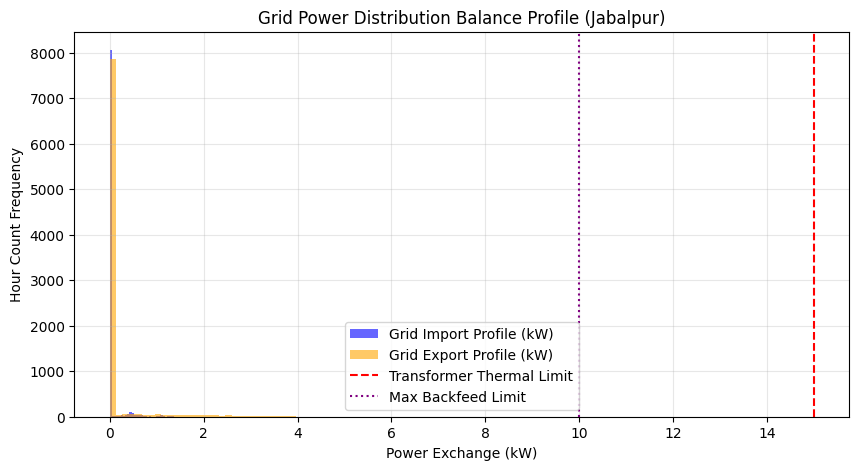

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define Grid/AC interconnection validation parameters
GRID_LIMITS = {
    "transformer_kva_limit": 15.0,  # Peak thermal transformer limit
    "max_backfeed_kw": 10.0,         # Maximum reverse active power export allowed by utility
    "target_power_factor": 0.95,     # Penalty threshold for low PF
    "max_voltage_deviation_pct": 5.0 # Max voltage rise limit from high export
}

def run_grid_ac_validation(dispatch_df, grid_limits):
    """
    Validates the simulated hourly dispatch trajectory against power system and grid connection rules.
    """
    print("=== GRID/AC INTERCONNECTION VALIDATION REPORT ===\n")

    # Peak Power Analysis
    peak_import = dispatch_df["grid_import_kw"].max()
    peak_export = dispatch_df["grid_export_kw"].max()

    # 1. Check Transformer Capacity Limit
    import_capacity_pass = peak_import <= grid_limits["transformer_kva_limit"]
    export_capacity_pass = peak_export <= grid_limits["transformer_kva_limit"]

    # 2. Check Utility Backfeed Limit
    backfeed_pass = peak_export <= grid_limits["max_backfeed_kw"]

    # 3. Voltage Deviation Approximation due to line impedance R (ohms)
    # approximated simply as dV % = (P_export * R) / V_nominal
    R_line_ohms = 0.5
    V_nominal_v = 230.0
    max_voltage_rise_v = (peak_export * 1000.0 * R_line_ohms) / V_nominal_v
    voltage_rise_pct = (max_voltage_rise_v / V_nominal_v) * 100.0
    voltage_pass = voltage_rise_pct <= grid_limits["max_voltage_deviation_pct"]

    print(f"1) Transformer Thermal Limit Check ({grid_limits['transformer_kva_limit']:.1f} kVA limit):")
    print(f"   - Peak Grid Import : {peak_import:.2f} kW | Status: {'PASS' if import_capacity_pass else 'FAIL (Overload risk)'}")
    print(f"   - Peak Grid Export : {peak_export:.2f} kW | Status: {'PASS' if export_capacity_pass else 'FAIL (Overload risk)'}\n")

    print(f"2) Reverse Power Backfeed Limit Check ({grid_limits['max_backfeed_kw']:.1f} kW limit):")
    print(f"   - Peak Active Power Export: {peak_export:.2f} kW | Status: {'PASS' if backfeed_pass else 'FAIL (Backfeed limit exceeded)'}\n")

    print(f"3) Local Point of Interconnection (POI) Voltage Rise estimation:")
    print(f"   - Estimated Max Voltage Rise: {voltage_rise_pct:.2f}% | Status: {'PASS' if voltage_pass else 'FAIL (Voltage Violation risk)'}\n")

    overall_pass = import_capacity_pass and export_capacity_pass and backfeed_pass and voltage_pass
    print(f"OVERALL AC/GRID INTERCONNECTION COMPLIANCE STATUS: {'🟢 APPROVED' if overall_pass else '🔴 REJECTED (Mitigation required)'}")
    print("=================================================")

    # Plot grid import vs export load profiles for visual energy balance
    plt.figure(figsize=(10, 5))
    plt.hist(dispatch_df["grid_import_kw"], bins=30, alpha=0.6, color='blue', label='Grid Import Profile (kW)')
    plt.hist(dispatch_df["grid_export_kw"], bins=30, alpha=0.6, color='orange', label='Grid Export Profile (kW)')
    plt.axvline(grid_limits["transformer_kva_limit"], color='red', linestyle='--', label='Transformer Thermal Limit')
    plt.axvline(grid_limits["max_backfeed_kw"], color='purple', linestyle=':', label='Max Backfeed Limit')
    plt.title("Grid Power Distribution Balance Profile (Jabalpur)")
    plt.xlabel("Power Exchange (kW)")
    plt.ylabel("Hour Count Frequency")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Run validation on the optimal dispatch dataset
run_grid_ac_validation(opt_result, GRID_LIMITS)